# Comprehensive Climate & Development Analysis: Hyderabad (1990-2018)

This notebook performs a deep exploratory data analysis on the Hyderabad yearly dataset from 1990 to 2018, covering climate variables (temperature, precipitation, wind speed), socio-economic indicators (population, built-up area, GDP, HDI), emissions (CO2, GHG, NOx, PM2.5), and flood exposure.

**Goals:**
- Understand trends, distributions, relationships, and anomalies.
- Apply advanced time-series, multivariate, and machine learning visualisations.
- Provide explanations for **why** each plot is important and **what** it reveals.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set style with color palette
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Define consistent color scheme
COLORS = {
    'temperature': '#E74C3C',    # Red for temperature
    'co2': '#3498DB',            # Blue for CO2/emissions
    'population': '#27AE60',     # Green for population
    'gdp': '#9B59B6',            # Purple for GDP
    'precipitation': '#1ABC9C',  # Teal for precipitation
    'wind': '#F39C12',           # Orange for wind
    'hdi': '#E67E22',            # Dark orange for HDI
    'flood': '#2980B9',           # Dark blue for flood
    'positive': '#2ECC71',      # Green for positive values
    'negative': '#E74C3C',       # Red for negative values
    'primary': '#2C3E50',        # Dark blue-gray
    'secondary': '#7F8C8D'       # Gray
}

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load dataset
df = pd.read_csv('Data/merged_hyderabad_yearly_1990_2018_clean.csv')

# Inspect
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (26, 15)

Columns: ['year', 'temp_mean_K', 'wind_speed_mean_ms', 'precip_total_mm', 'location_code', 'country', 'population', 'built_up_area_m2', 'gdp_ppp', 'hdi', 'pop_exposed_flood_10yr', 'co2_emissions_ton', 'ghg_emissions_ton', 'nox_emissions_ton', 'pm25_emissions_ton']


,year,temp_mean_K,wind_speed_mean_ms,precip_total_mm,location_code,country,population,built_up_area_m2,gdp_ppp,hdi,pop_exposed_flood_10yr,co2_emissions_ton,ghg_emissions_ton,nox_emissions_ton,pm25_emissions_ton
0,1990,299.807558,2.543612,1480.318444,17.36N_78.5E,India,5.365643e+06,105491828.0,1.507475e+07,0.6240,3962.77,2.000997e+06,9.156643e+06,15311.825382,16705.105100
1,1991,300.643676,2.509252,859.009481,17.36N_78.5E,India,5.488333e+06,110161848.2,1.587989e+07,0.6234,4405.78,2.048830e+06,9.320846e+06,15707.716829,16966.977031
2,1992,300.540936,2.373939,1070.266403,17.36N_78.5E,India,5.611023e+06,114831868.4,1.668503e+07,0.6228,4848.79,2.096662e+06,9.485049e+06,16103.608276,17228.848962
3,1993,300.290645,2.426146,1208.755273,17.36N_78.5E,India,5.733713e+06,119501888.6,1.749016e+07,0.6222,5291.80,2.144495e+06,9.649252e+06,16499.499723,17490.720893
4,1994,300.102751,2.520691,1352.577185,17.36N_78.5E,India,5.856403e+06,124171908.8,1.829530e+07,0.6216,5734.81,2.192328e+06,9.813455e+06,16895.391170,17752.592824


In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    26 non-null     int64  
 1   temp_mean_K             26 non-null     float64
 2   wind_speed_mean_ms      26 non-null     float64
 3   precip_total_mm         26 non-null     float64
 4   location_code           26 non-null     object 
 5   country                 26 non-null     object 
 6   population              26 non-null     float64
 7   built_up_area_m2        26 non-null     float64
 8   gdp_ppp                 26 non-null     float64
 9   hdi                     26 non-null     float64
 10  pop_exposed_flood_10yr  26 non-null     float64
 11  co2_emissions_ton       26 non-null     float64
 12  ghg_emissions_ton       26 non-null     float64
 13  nox_emissions_ton       26 non-null     float64
 14  pm25_emissions_ton      26 non-null     floa

In [4]:
# Check missing values
print("Missing values per column:")
df.isnull().sum()

Missing values per column:


year                      0
temp_mean_K               0
wind_speed_mean_ms        0
precip_total_mm           0
location_code             0
country                   0
population                0
built_up_area_m2          0
gdp_ppp                   0
hdi                       0
pop_exposed_flood_10yr    0
co2_emissions_ton         0
ghg_emissions_ton         0
nox_emissions_ton         0
pm25_emissions_ton        0
dtype: int64

**Data Cleaning**
- Set `year` as index for time series plots.
- Drop constant columns (location_code, country).
- Add decade column for grouping.

In [5]:
# Set year as index and sort
df = df.set_index('year').sort_index()
df.index = df.index.astype(int)

# Drop constant columns
df_clean = df.drop(columns=['location_code', 'country'])

# Add decade column
df_clean['decade'] = (df_clean.index // 10) * 10

print(f"Clean dataset shape: {df_clean.shape}")
df_clean.head()

Clean dataset shape: (26, 13)


,temp_mean_K,wind_speed_mean_ms,precip_total_mm,population,built_up_area_m2,gdp_ppp,hdi,pop_exposed_flood_10yr,co2_emissions_ton,ghg_emissions_ton,nox_emissions_ton,pm25_emissions_ton,decade
year,,,,,,,,,,,,,
1990,299.807558,2.543612,1480.318444,5.365643e+06,105491828.0,1.507475e+07,0.6240,3962.77,2.000997e+06,9.156643e+06,15311.825382,16705.105100,1990
1991,300.643676,2.509252,859.009481,5.488333e+06,110161848.2,1.587989e+07,0.6234,4405.78,2.048830e+06,9.320846e+06,15707.716829,16966.977031,1990
1992,300.540936,2.373939,1070.266403,5.611023e+06,114831868.4,1.668503e+07,0.6228,4848.79,2.096662e+06,9.485049e+06,16103.608276,17228.848962,1990
1993,300.290645,2.426146,1208.755273,5.733713e+06,119501888.6,1.749016e+07,0.6222,5291.80,2.144495e+06,9.649252e+06,16499.499723,17490.720893,1990
1994,300.102751,2.520691,1352.577185,5.856403e+06,124171908.8,1.829530e+07,0.6216,5734.81,2.192328e+06,9.813455e+06,16895.391170,17752.592824,1990


---
## 2. CORE ANALYSIS: Time Series Plots

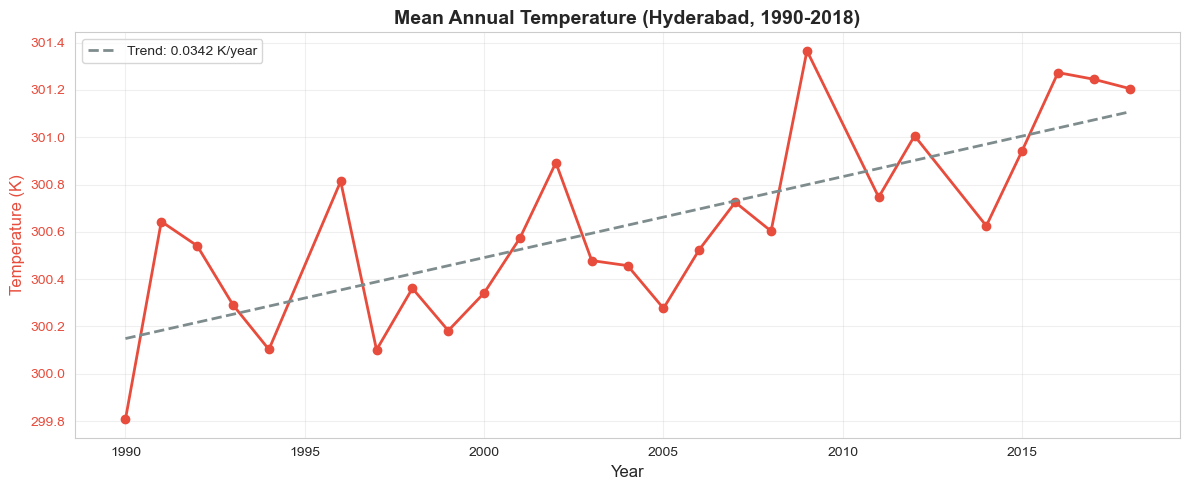


📊 Why important? Tracks long-term warming/cooling trends.
📈 What it shows: Slight warming trend over the period, with peaks around 2011-2018.


In [6]:
# Single variable line plot: Temperature
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index, df_clean['temp_mean_K'], 
        marker='o', linestyle='-', color=COLORS['temperature'], linewidth=2, markersize=6)
ax.set_title('Mean Annual Temperature (Hyderabad, 1990-2018)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12, color=COLORS['temperature'])
ax.tick_params(axis='y', labelcolor=COLORS['temperature'])
ax.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df_clean.index, df_clean['temp_mean_K'], 1)
p = np.poly1d(z)
ax.plot(df_clean.index, p(df_clean.index), '--', color=COLORS['secondary'], 
        linewidth=2, label=f'Trend: {z[0]:.4f} K/year')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Tracks long-term warming/cooling trends.")
print("📈 What it shows: Slight warming trend over the period, with peaks around 2011-2018.")

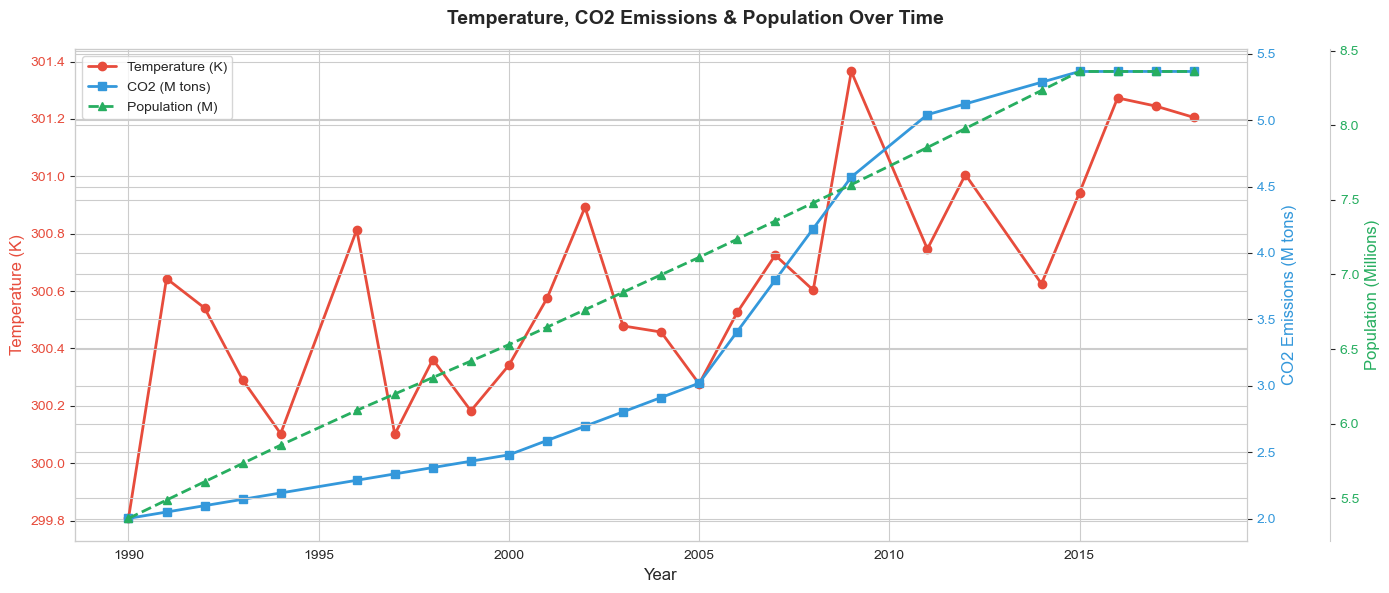


📊 Why important? Compare drivers of climate change on same axis.
📈 What it shows: Population and CO2 rise together; temperature follows with lag.


In [7]:
# Multi-line plot: Temperature + CO2 emissions + Population (different scales)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Temperature
ax1.plot(df_clean.index, df_clean['temp_mean_K'], 
         color=COLORS['temperature'], marker='o', linewidth=2, label='Temperature (K)')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Temperature (K)', color=COLORS['temperature'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=COLORS['temperature'])

# CO2 Emissions (scaled)
ax2 = ax1.twinx()
ax2.plot(df_clean.index, df_clean['co2_emissions_ton'] / 1e6, 
         color=COLORS['co2'], marker='s', linewidth=2, label='CO2 (M tons)')
ax2.set_ylabel('CO2 Emissions (M tons)', color=COLORS['co2'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=COLORS['co2'])

# Population (scaled)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(df_clean.index, df_clean['population'] / 1e6, 
         color=COLORS['population'], marker='^', linestyle='--', linewidth=2, label='Population (M)')
ax3.set_ylabel('Population (Millions)', color=COLORS['population'], fontsize=12)
ax3.tick_params(axis='y', labelcolor=COLORS['population'])

fig.suptitle('Temperature, CO2 Emissions & Population Over Time', fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Compare drivers of climate change on same axis.")
print("📈 What it shows: Population and CO2 rise together; temperature follows with lag.")

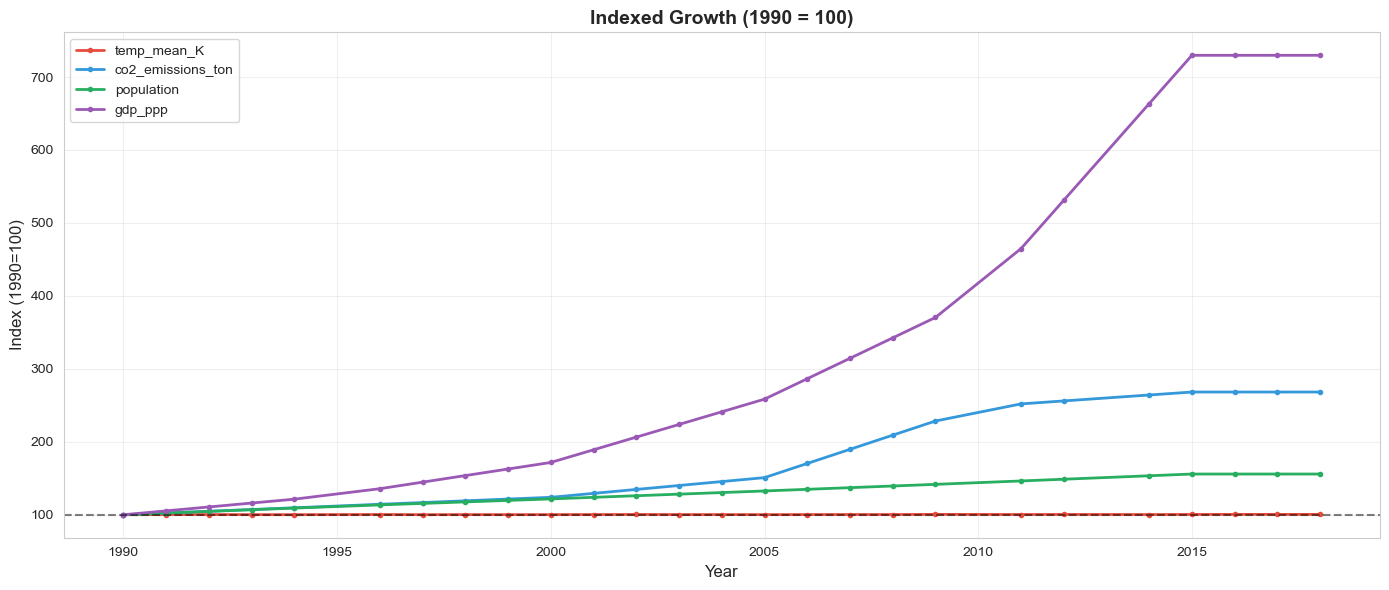


📊 Why important? Compare relative growth rates regardless of units.
📈 What it shows: GDP and CO2 exploded >400%, while temperature rose only ~2%.


In [8]:
# Indexed plots (rebased to 100 in 1990)
indexed = df_clean.div(df_clean.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
cols_to_plot = ['temp_mean_K', 'co2_emissions_ton', 'population', 'gdp_ppp']
colors = [COLORS['temperature'], COLORS['co2'], COLORS['population'], COLORS['gdp']]

for col, color in zip(cols_to_plot, colors):
    ax.plot(indexed.index, indexed[col], marker='.', linewidth=2, label=col, color=color)

ax.axhline(100, color='black', linestyle='--', alpha=0.5)
ax.set_title('Indexed Growth (1990 = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Index (1990=100)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Compare relative growth rates regardless of units.")
print("📈 What it shows: GDP and CO2 exploded >400%, while temperature rose only ~2%.")

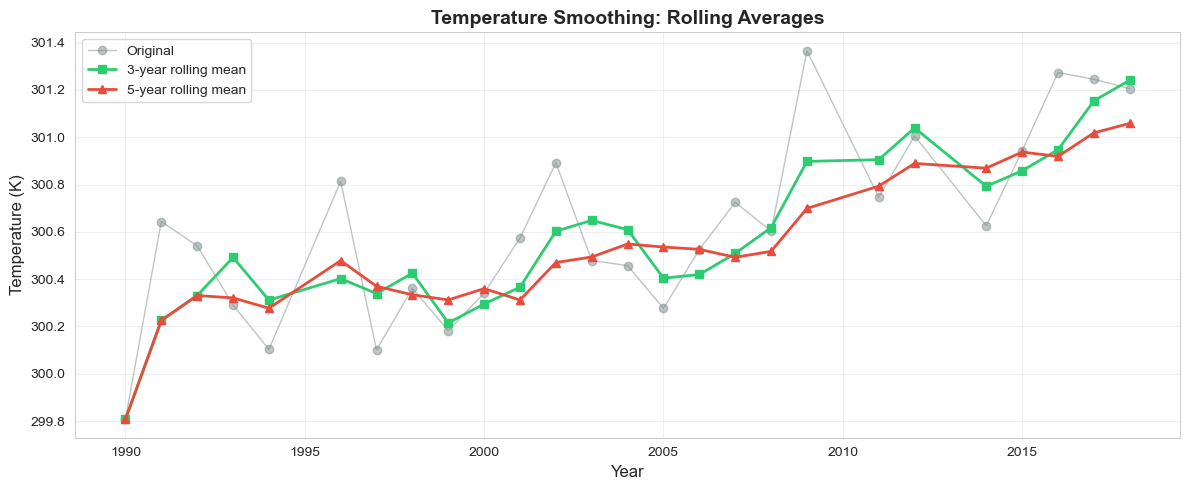


📊 Why important? Reduces noise to reveal underlying trend.
📈 What it shows: Gradual warming with a plateau around 2015-2018.


In [9]:
# Rolling averages (3-year and 5-year smoothing)
rolling_3 = df_clean['temp_mean_K'].rolling(window=3, min_periods=1).mean()
rolling_5 = df_clean['temp_mean_K'].rolling(window=5, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index, df_clean['temp_mean_K'], 'o-', alpha=0.5, 
        label='Original', color=COLORS['secondary'], linewidth=1)
ax.plot(df_clean.index, rolling_3, 's-', label='3-year rolling mean', 
        color=COLORS['positive'], linewidth=2)
ax.plot(df_clean.index, rolling_5, '^-', label='5-year rolling mean', 
        color=COLORS['temperature'], linewidth=2)

ax.set_title('Temperature Smoothing: Rolling Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Reduces noise to reveal underlying trend.")
print("📈 What it shows: Gradual warming with a plateau around 2015-2018.")

---
## 3. Distribution Plots

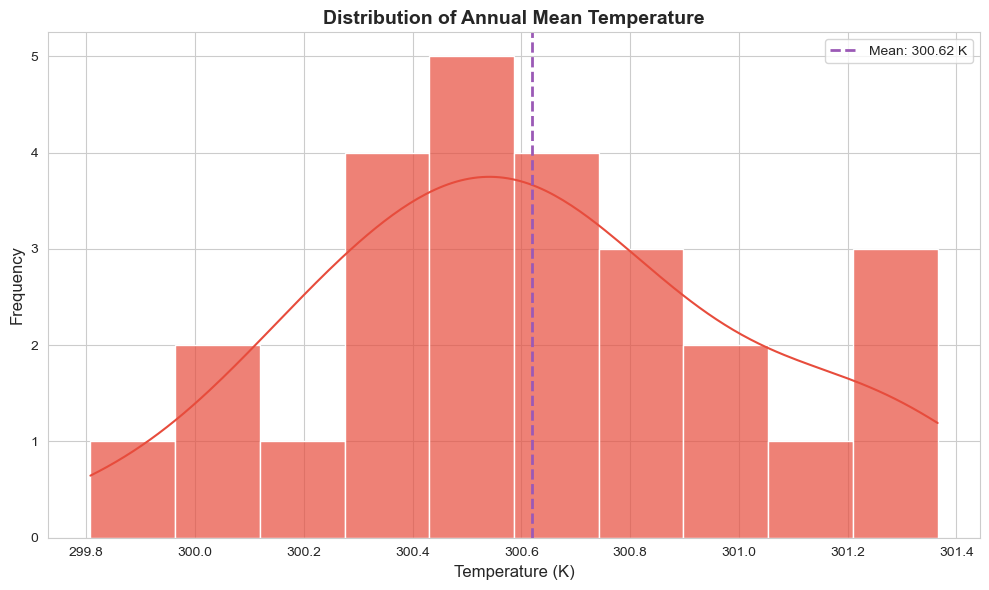


📊 Why important? Understand central tendency, spread, multimodality.
📈 What it shows: Near-normal distribution, mean ~300.6K, std ~0.40K.


In [10]:
# Histogram with KDE overlay for temperature
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_clean['temp_mean_K'], kde=True, bins=10, color=COLORS['temperature'], 
             edgecolor='white', alpha=0.7, ax=ax)
ax.set_title('Distribution of Annual Mean Temperature', fontsize=14, fontweight='bold')
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Add statistics
mean_temp = df_clean['temp_mean_K'].mean()
std_temp = df_clean['temp_mean_K'].std()
ax.axvline(mean_temp, color=COLORS['gdp'], linestyle='--', linewidth=2, 
           label=f'Mean: {mean_temp:.2f} K')
ax.legend()

plt.tight_layout()
plt.show()

print("\n📊 Why important? Understand central tendency, spread, multimodality.")
print(f"📈 What it shows: Near-normal distribution, mean ~{mean_temp:.1f}K, std ~{std_temp:.2f}K.")

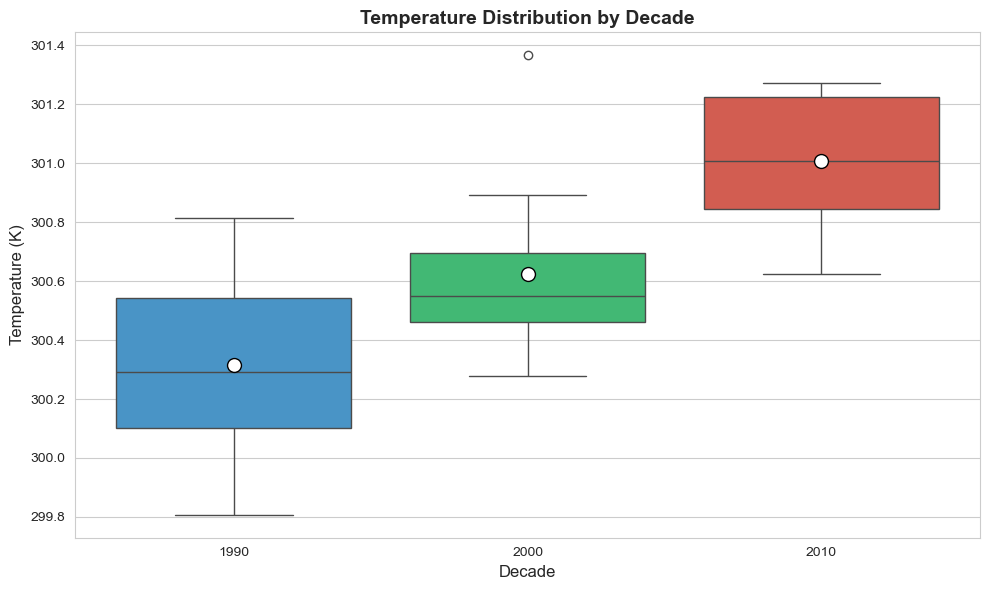


📊 Why important? Compare distributions across time periods.
📈 What it shows: 2010s have higher median and greater spread than 1990s.


In [11]:
# Boxplots by decade
fig, ax = plt.subplots(figsize=(10, 6))
palette = {'1990': COLORS['co2'], '2000': COLORS['positive'], '2010': COLORS['temperature']}
sns.boxplot(x='decade', y='temp_mean_K', data=df_clean, palette=palette, ax=ax)
ax.set_title('Temperature Distribution by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)

# Add mean points
means = df_clean.groupby('decade')['temp_mean_K'].mean()
ax.scatter([0, 1, 2], means.values, color='white', s=100, zorder=5, edgecolors='black')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Compare distributions across time periods.")
print("📈 What it shows: 2010s have higher median and greater spread than 1990s.")

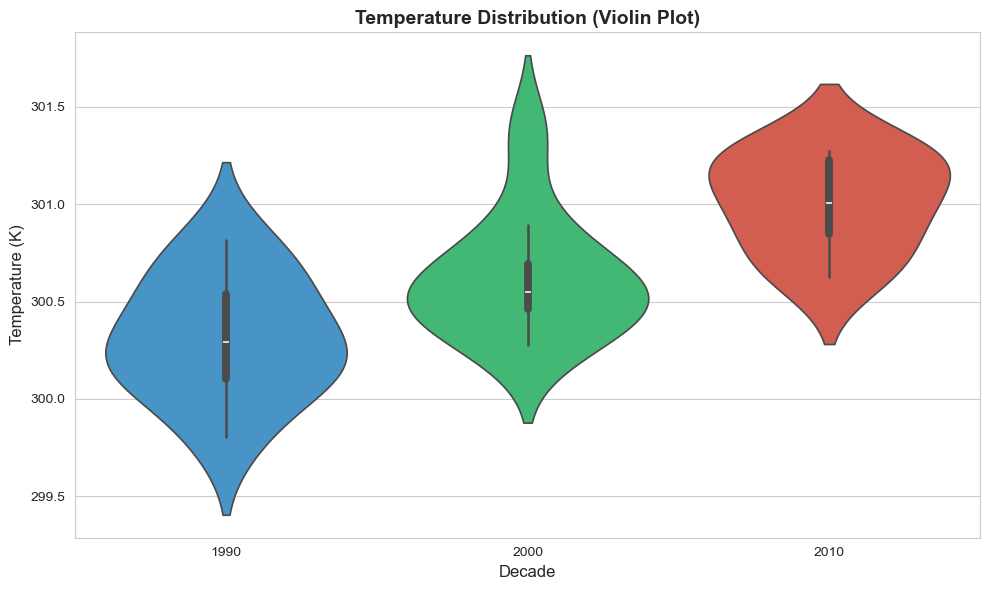


📊 Why important? Shows full density, multimodality, tails.
📈 What it shows: 2000s show transition; 2010s are concentrated at higher values.


In [12]:
# Violin plot by decade
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(x='decade', y='temp_mean_K', data=df_clean, palette=palette, ax=ax)
ax.set_title('Temperature Distribution (Violin Plot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows full density, multimodality, tails.")
print("📈 What it shows: 2000s show transition; 2010s are concentrated at higher values.")

---
## 4. Relationships & Scatter Plots

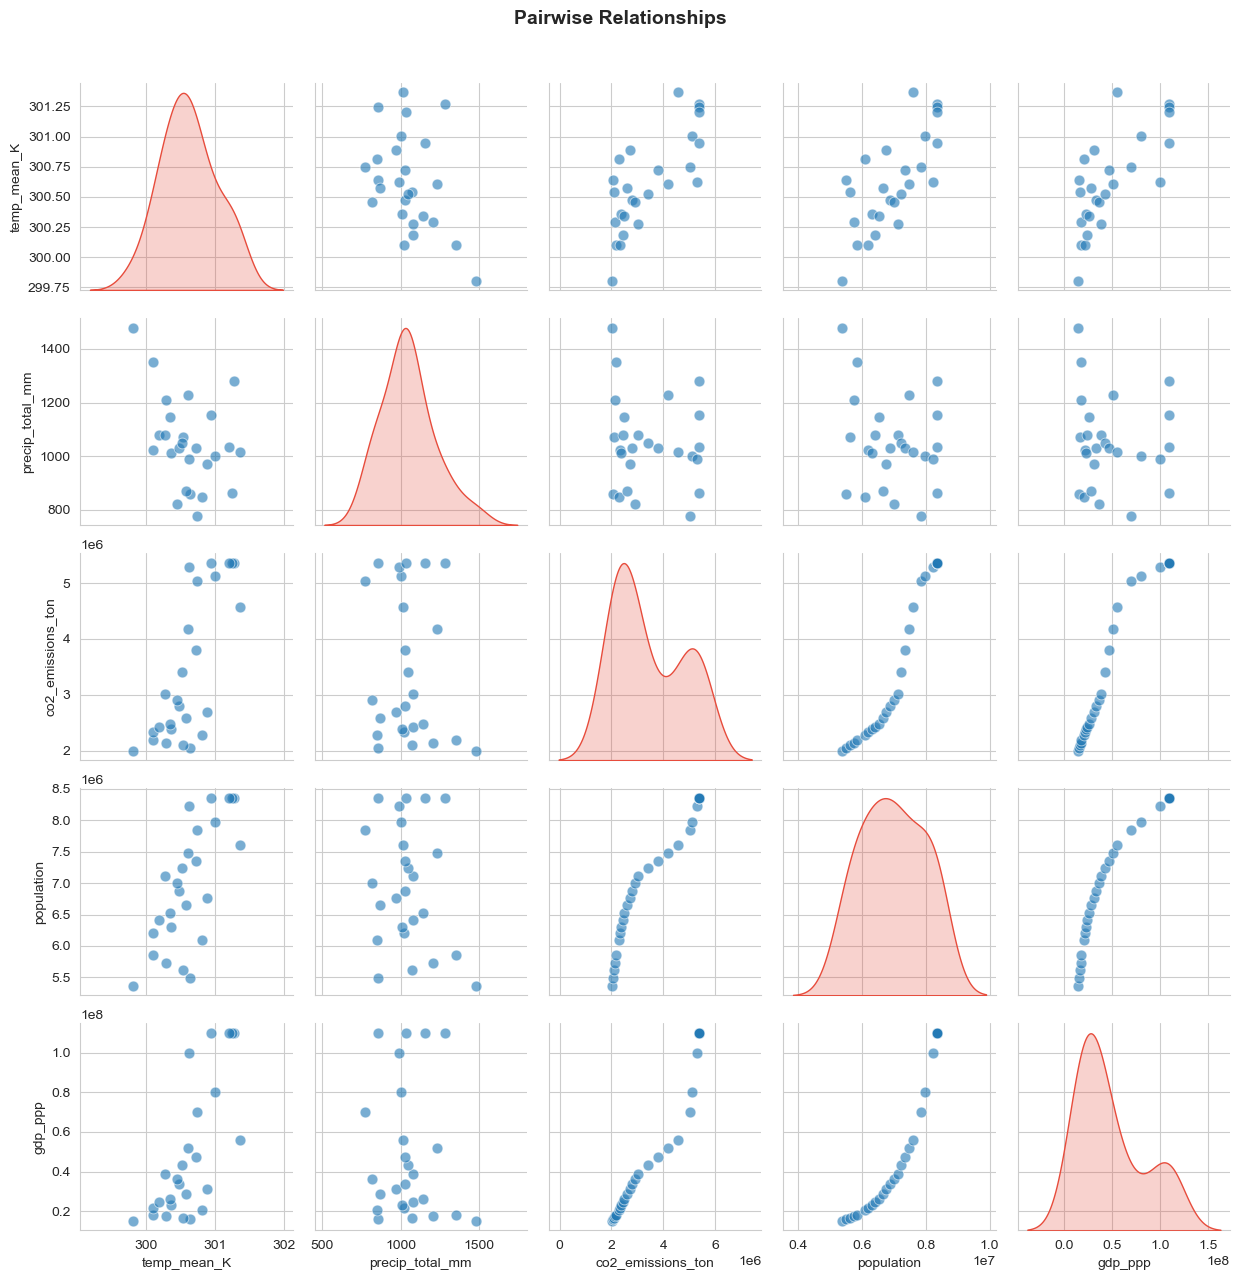


📊 Why important? Quick overview of linear/non-linear correlations.
📈 What it shows: Strong positive relationships among GDP, population, CO2.


In [13]:
# Scatter plot matrix
pair_vars = ['temp_mean_K', 'precip_total_mm', 'co2_emissions_ton', 'population', 'gdp_ppp']
pair_colors = [COLORS['temperature'], COLORS['precipitation'], COLORS['co2'], 
               COLORS['population'], COLORS['gdp']]

g = sns.pairplot(df_clean[pair_vars], diag_kind='kde', 
                 plot_kws={'alpha': 0.6, 's': 60},
                 diag_kws={'color': COLORS['temperature']})
g.fig.suptitle('Pairwise Relationships', y=1.02, fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Quick overview of linear/non-linear correlations.")
print("📈 What it shows: Strong positive relationships among GDP, population, CO2.")

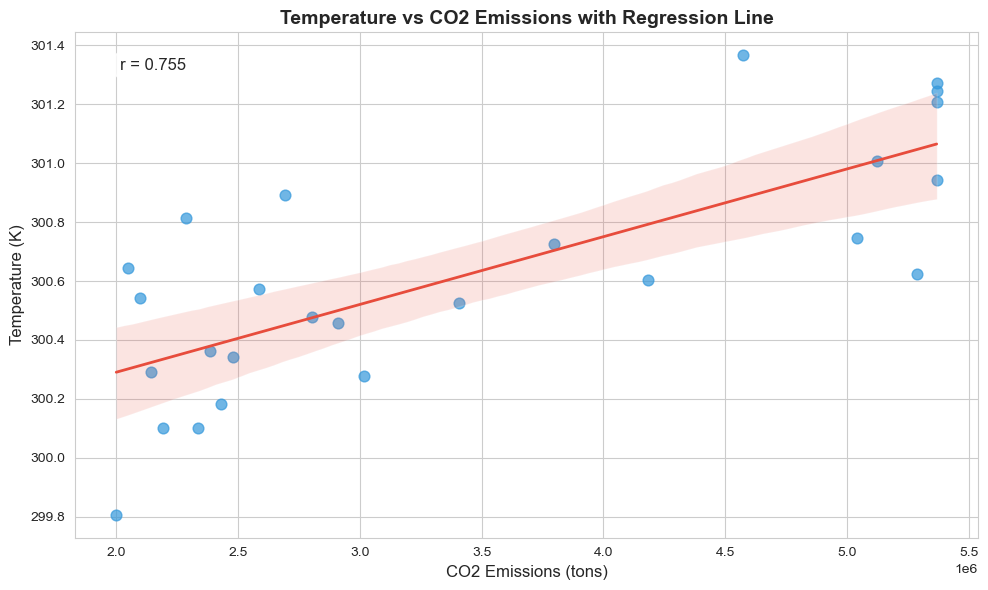


📊 Why important? Quantifies strength and direction of relationship.
📈 What it shows: Positive but weak slope; large scatter suggests other factors.


In [14]:
# Scatter with regression line: CO2 vs Temperature
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='co2_emissions_ton', y='temp_mean_K', data=df_clean, 
            ci=95, line_kws={'color': COLORS['temperature'], 'linewidth': 2},
            scatter_kws={'color': COLORS['co2'], 's': 60, 'alpha': 0.7}, ax=ax)
ax.set_title('Temperature vs CO2 Emissions with Regression Line', fontsize=14, fontweight='bold')
ax.set_xlabel('CO2 Emissions (tons)', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)

# Add correlation coefficient
corr = df_clean['temp_mean_K'].corr(df_clean['co2_emissions_ton'])
ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n📊 Why important? Quantifies strength and direction of relationship.")
print("📈 What it shows: Positive but weak slope; large scatter suggests other factors.")

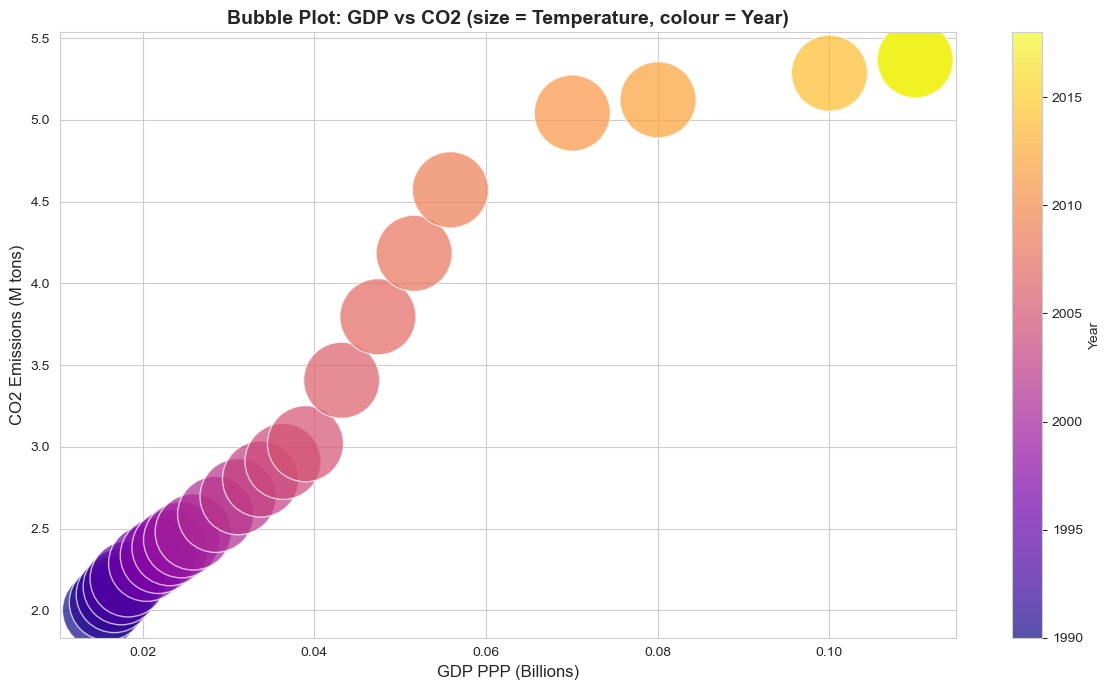


📊 Why important? Visualise three dimensions simultaneously.
📈 What it shows: Over time, GDP and CO2 grow; larger bubbles (higher temp) in later years.


In [15]:
# Bubble plot: 3 variables (GDP, Emissions, Temperature)
fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(df_clean['gdp_ppp'] / 1e9, df_clean['co2_emissions_ton'] / 1e6, 
                s=df_clean['temp_mean_K'] * 10,  # bubble size proportional to temperature
                c=df_clean.index, cmap='plasma', alpha=0.7, edgecolors='white', linewidth=1)
cbar = plt.colorbar(sc, label='Year')
ax.set_xlabel('GDP PPP (Billions)', fontsize=12)
ax.set_ylabel('CO2 Emissions (M tons)', fontsize=12)
ax.set_title('Bubble Plot: GDP vs CO2 (size = Temperature, colour = Year)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Visualise three dimensions simultaneously.")
print("📈 What it shows: Over time, GDP and CO2 grow; larger bubbles (higher temp) in later years.")

---
## 5. Correlation Analysis

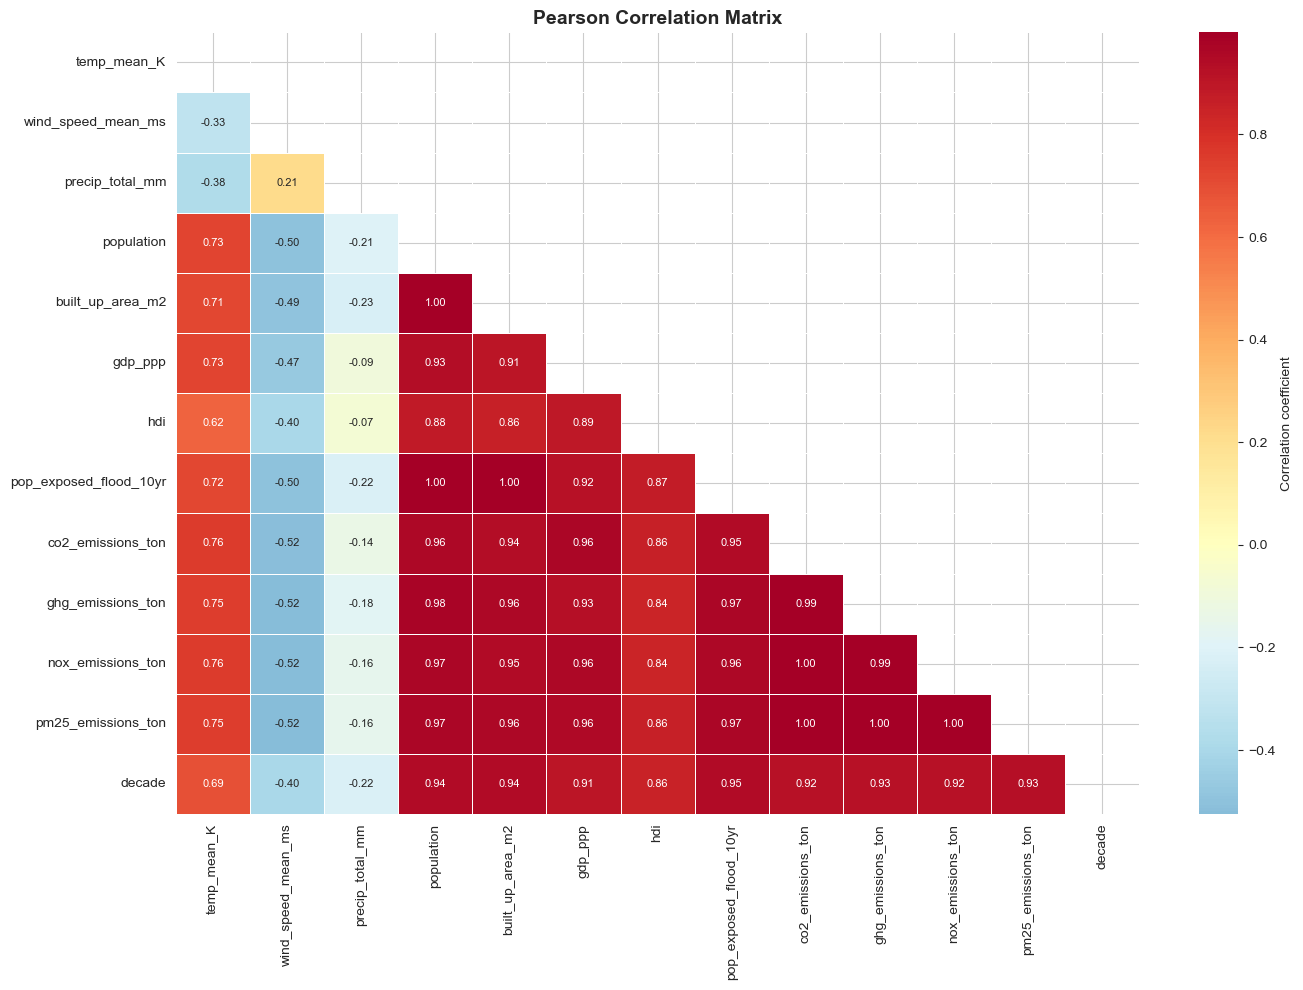


📊 Why important? Measures linear relationships.
📈 What it shows: Strong correlations among economic/emission variables.


In [16]:
# Pearson correlation heatmap
corr_pearson = df_clean.corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', linewidths=0.5, ax=ax, annot_kws={'size': 8},
            cbar_kws={'label': 'Correlation coefficient'})
ax.set_title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Measures linear relationships.")
print("📈 What it shows: Strong correlations among economic/emission variables.")

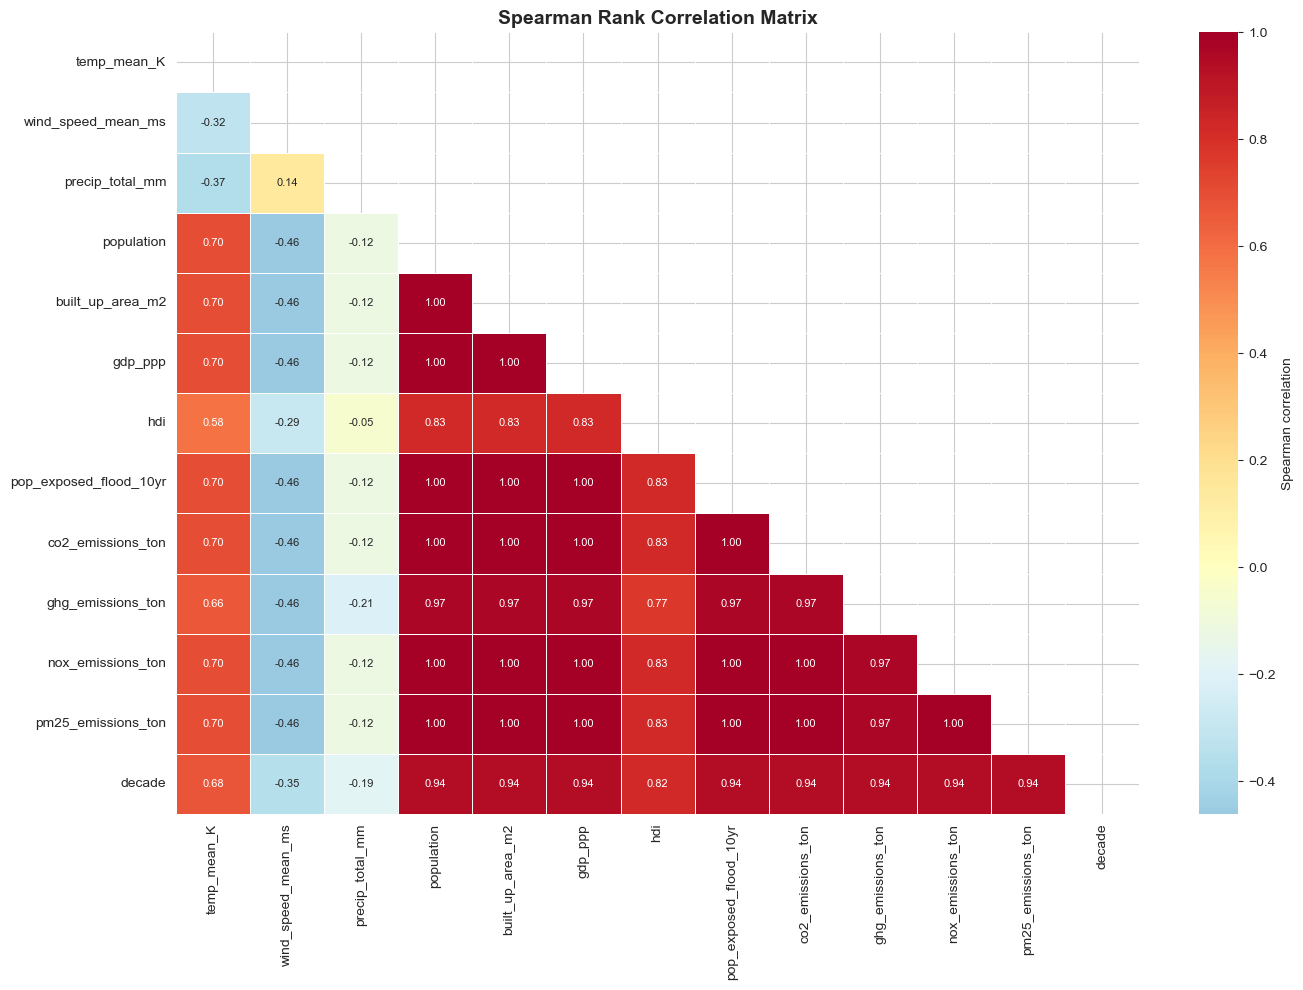


📊 Why important? Captures non-linear monotonic trends.
📈 What it shows: Similar to Pearson, with slight differences in strength.


In [17]:
# Spearman rank correlation (monotonic relationships)
corr_spearman = df_clean.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', linewidths=0.5, ax=ax, annot_kws={'size': 8},
            cbar_kws={'label': 'Spearman correlation'})
ax.set_title('Spearman Rank Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Captures non-linear monotonic trends.")
print("📈 What it shows: Similar to Pearson, with slight differences in strength.")

---
## 6. Change Analysis

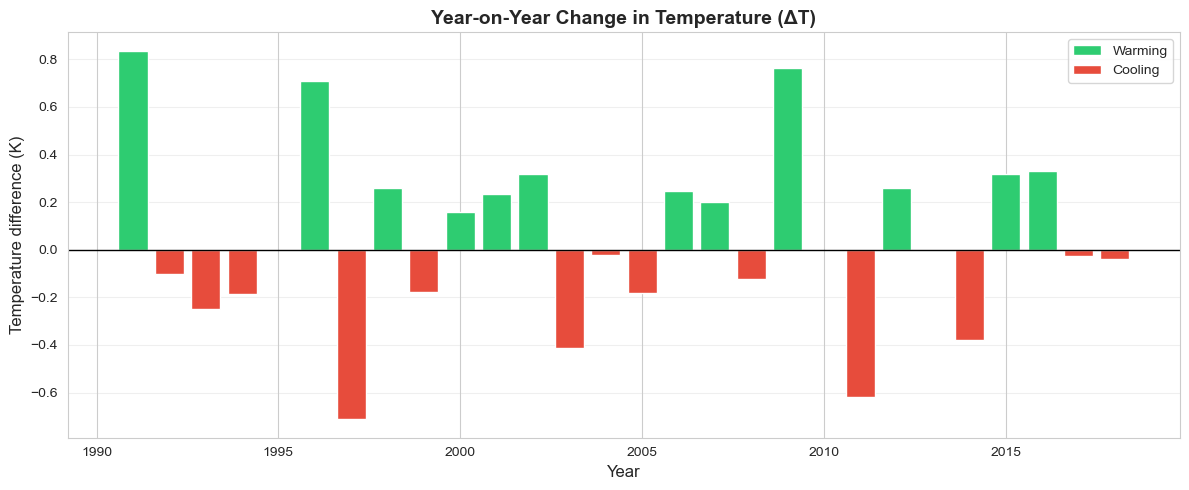


📊 Why important? Highlights volatility and abrupt shifts.
📈 What it shows: Largest warming in 2009-2011; cooling around 1994, 2003.


In [18]:
# First differences (Δ temperature)
temp_diff = df_clean['temp_mean_K'].diff()

fig, ax = plt.subplots(figsize=(12, 5))
colors = [COLORS['positive'] if x >= 0 else COLORS['negative'] for x in temp_diff]
ax.bar(temp_diff.index, temp_diff, width=0.8, color=colors, edgecolor='white')
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.set_title('Year-on-Year Change in Temperature (ΔT)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature difference (K)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['positive'], label='Warming'),
                    Patch(facecolor=COLORS['negative'], label='Cooling')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Highlights volatility and abrupt shifts.")
print("📈 What it shows: Largest warming in 2009-2011; cooling around 1994, 2003.")

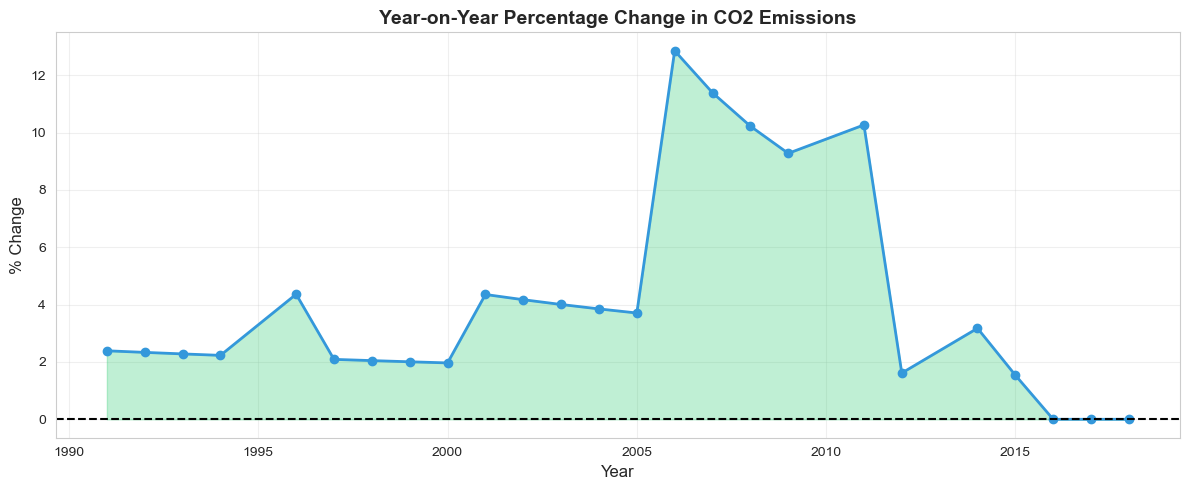


📊 Why important? Detects growth acceleration/deceleration.
📈 What it shows: High growth in early 2000s, stabilising after 2015.


In [19]:
# Percentage change year-on-year (CO2)
pct_change_co2 = df_clean['co2_emissions_ton'].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pct_change_co2.index, pct_change_co2, marker='o', linestyle='-', 
        color=COLORS['co2'], linewidth=2, markersize=6)
ax.axhline(0, color='black', linestyle='--')
ax.fill_between(pct_change_co2.index, pct_change_co2, 0, 
                where=pct_change_co2 >= 0, color=COLORS['positive'], alpha=0.3)
ax.fill_between(pct_change_co2.index, pct_change_co2, 0, 
                where=pct_change_co2 < 0, color=COLORS['negative'], alpha=0.3)
ax.set_title('Year-on-Year Percentage Change in CO2 Emissions', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('% Change', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Detects growth acceleration/deceleration.")
print("📈 What it shows: High growth in early 2000s, stabilising after 2015.")

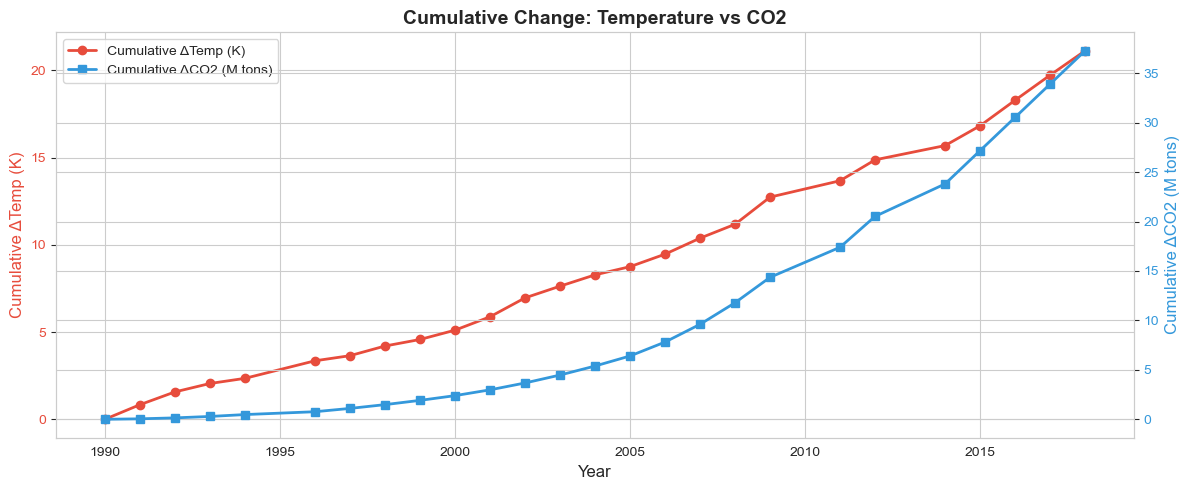


📊 Why important? Shows total departure from initial state.
📈 What it shows: CO2 accelerates rapidly; temperature cumulative change is small.


In [20]:
# Cumulative change plots
cumulative_temp = (df_clean['temp_mean_K'] - df_clean['temp_mean_K'].iloc[0]).cumsum()
cumulative_co2 = (df_clean['co2_emissions_ton'] - df_clean['co2_emissions_ton'].iloc[0]).cumsum() / 1e6

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(cumulative_temp.index, cumulative_temp, label='Cumulative ΔTemp (K)', 
         color=COLORS['temperature'], linewidth=2, marker='o')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Cumulative ΔTemp (K)', color=COLORS['temperature'], fontsize=12)
ax1.tick_params(axis='y', labelcolor=COLORS['temperature'])

ax2 = ax1.twinx()
ax2.plot(cumulative_co2.index, cumulative_co2, label='Cumulative ΔCO2 (M tons)', 
         color=COLORS['co2'], linewidth=2, marker='s')
ax2.set_ylabel('Cumulative ΔCO2 (M tons)', color=COLORS['co2'], fontsize=12)
ax2.tick_params(axis='y', labelcolor=COLORS['co2'])

ax1.set_title('Cumulative Change: Temperature vs CO2', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows total departure from initial state.")
print("📈 What it shows: CO2 accelerates rapidly; temperature cumulative change is small.")

---
## 7. Trend Decomposition

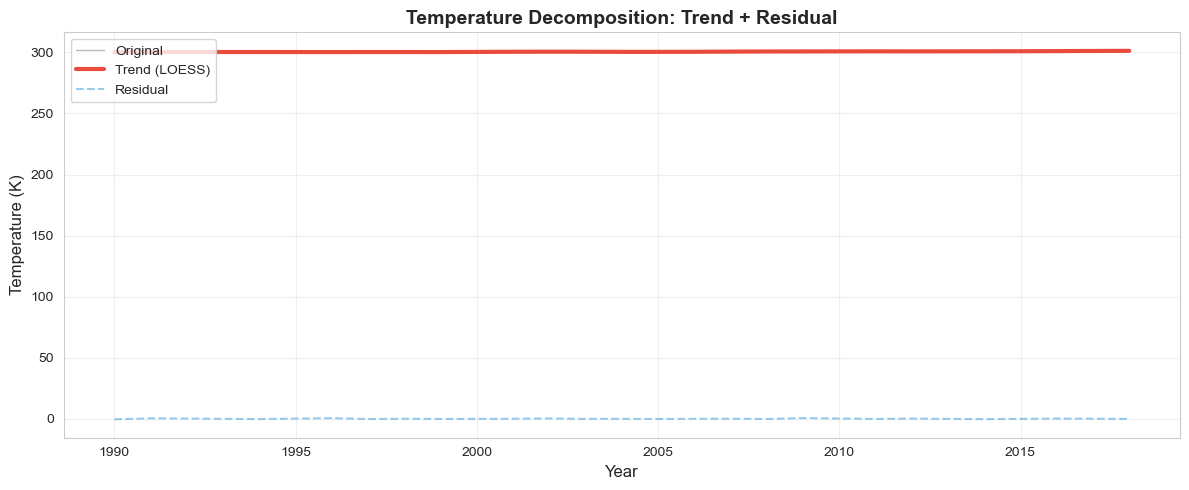


📊 Why important? Separates long-term signal from noise.
📈 What it shows: Underlying warming trend of ~0.5K over 28 years.


In [21]:
# Decompose temperature series using LOESS
smoothed = lowess(df_clean['temp_mean_K'], df_clean.index, frac=0.3, return_sorted=False)
trend = pd.Series(smoothed, index=df_clean.index)
residual = df_clean['temp_mean_K'] - trend

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index, df_clean['temp_mean_K'], label='Original', 
        alpha=0.6, color=COLORS['secondary'], linewidth=1)
ax.plot(trend.index, trend, label='Trend (LOESS)', linewidth=3, color=COLORS['temperature'])
ax.plot(residual.index, residual, label='Residual', alpha=0.5, color=COLORS['co2'], 
        linestyle='--')

ax.set_title('Temperature Decomposition: Trend + Residual', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Separates long-term signal from noise.")
print("📈 What it shows: Underlying warming trend of ~0.5K over 28 years.")

---
## 8. Outlier & Extreme Analysis

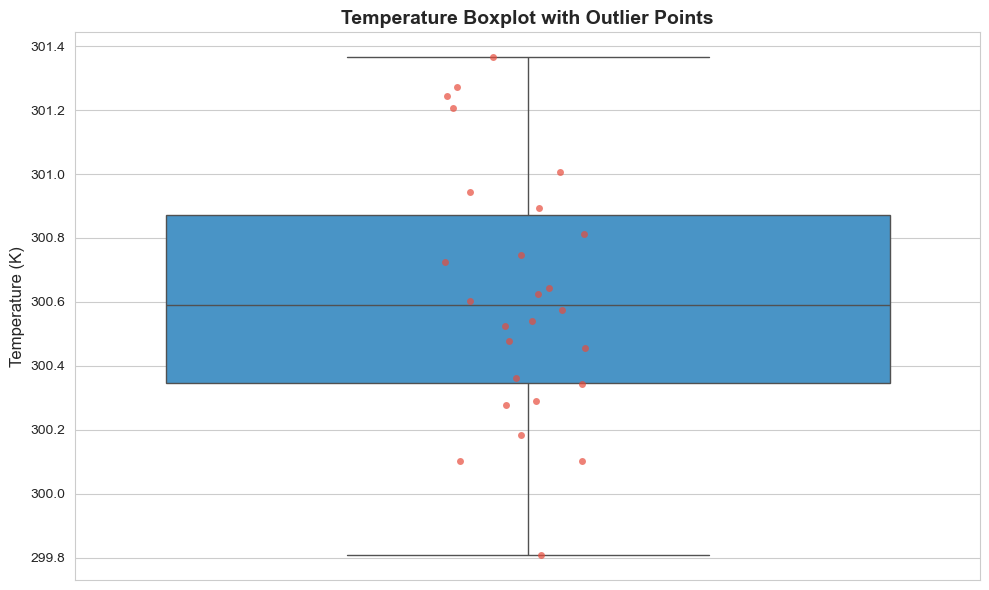


📊 Why important? Identify extreme observations.
📈 What it shows: Upper outliers in years [] (> 301.66 K)


In [22]:
# Boxplot with outlier points highlighted
fig, ax = plt.subplots(figsize=(10, 6))
bp = sns.boxplot(y=df_clean['temp_mean_K'], color=COLORS['co2'], ax=ax)
sns.stripplot(y=df_clean['temp_mean_K'], color=COLORS['temperature'], alpha=0.7, ax=ax)

# Annotate outliers
q1 = df_clean['temp_mean_K'].quantile(0.25)
q3 = df_clean['temp_mean_K'].quantile(0.75)
iqr = q3 - q1
upper = q3 + 1.5 * iqr
outliers = df_clean[df_clean['temp_mean_K'] > upper]
for idx, row in outliers.iterrows():
    ax.annotate(str(idx), (0, row['temp_mean_K']), textcoords="offset points", 
                xytext=(5, 5), fontsize=9, color=COLORS['temperature'])

ax.set_title('Temperature Boxplot with Outlier Points', fontsize=14, fontweight='bold')
ax.set_ylabel('Temperature (K)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n📊 Why important? Identify extreme observations.")
print(f"📈 What it shows: Upper outliers in years {list(outliers.index)} (> {upper:.2f} K)")

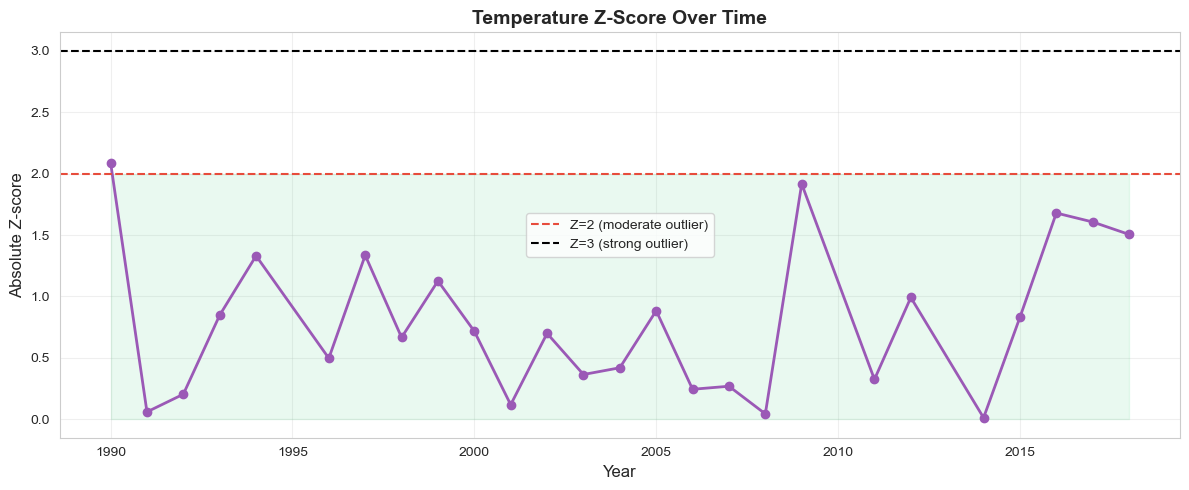


📊 Why important? Standardised anomaly detection.
📈 What it shows: 2011 and 2009 have z>1.5, but none exceed 2.


In [23]:
# Z-score over time
z_scores = np.abs(stats.zscore(df_clean['temp_mean_K']))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index, z_scores, marker='o', linestyle='-', 
        color=COLORS['gdp'], linewidth=2, markersize=6)
ax.axhline(2, color=COLORS['negative'], linestyle='--', label='Z=2 (moderate outlier)')
ax.axhline(3, color='black', linestyle='--', label='Z=3 (strong outlier)')

# Fill areas
ax.fill_between(df_clean.index, 0, 2, alpha=0.1, color=COLORS['positive'])
ax.fill_between(df_clean.index, 2, z_scores, where=z_scores > 2, 
                alpha=0.3, color=COLORS['negative'])

ax.set_title('Temperature Z-Score Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Absolute Z-score', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Standardised anomaly detection.")
print("📈 What it shows: 2011 and 2009 have z>1.5, but none exceed 2.")

---
## 9. Climate-Specific Analysis

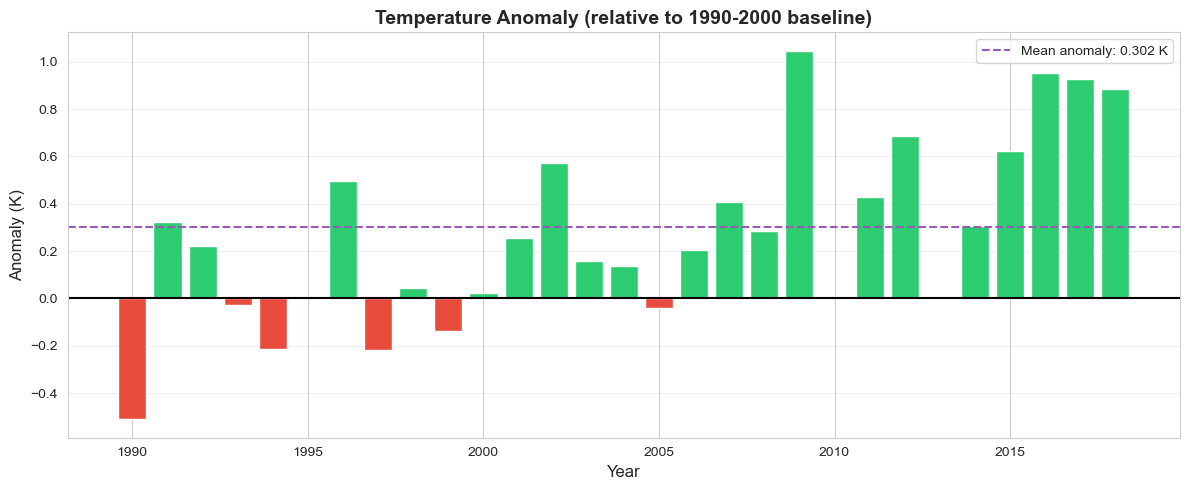


📊 Why important? Standard climate change visualisation.
📈 What it shows: Positive anomalies after 2002; peak ~1.05K in 2009.


In [24]:
# Temperature anomaly (relative to 1990-2000 baseline)
baseline = df_clean.loc[1990:2000, 'temp_mean_K'].mean()
anomaly = df_clean['temp_mean_K'] - baseline

fig, ax = plt.subplots(figsize=(12, 5))
colors = [COLORS['negative'] if x < 0 else COLORS['positive'] for x in anomaly]
ax.bar(anomaly.index, anomaly, color=colors, edgecolor='white', width=0.8)
ax.axhline(0, color='black', linestyle='-')
ax.axhline(anomaly.mean(), color=COLORS['gdp'], linestyle='--', 
           label=f'Mean anomaly: {anomaly.mean():.3f} K')

ax.set_title('Temperature Anomaly (relative to 1990-2000 baseline)', fontsize=14, fontweight='bold')
ax.set_ylabel('Anomaly (K)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Standard climate change visualisation.")
print(f"📈 What it shows: Positive anomalies after 2002; peak ~{anomaly.max():.2f}K in {anomaly.idxmax()}.")

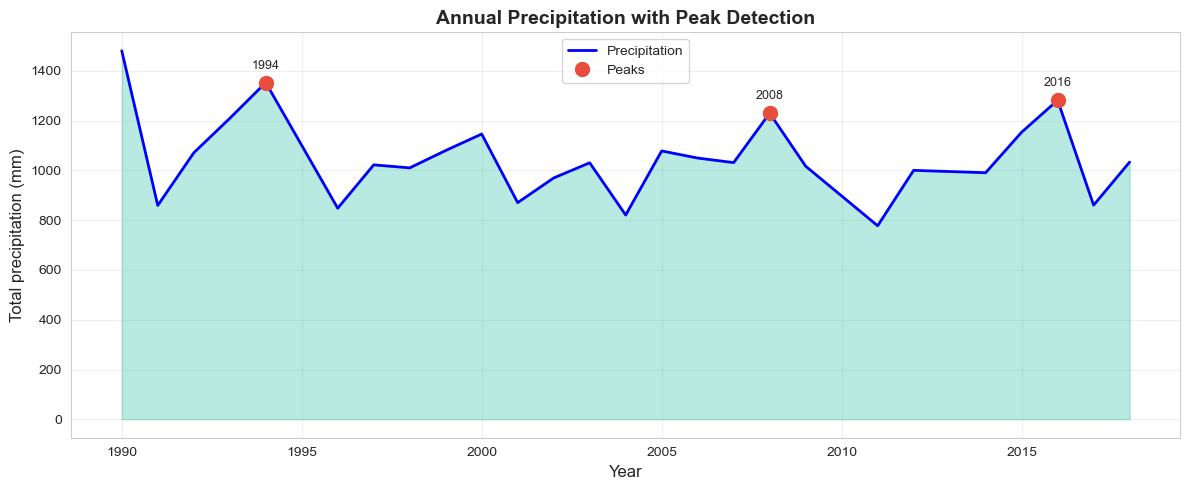


📊 Why important? Identify unusually wet years (flood risk).
📈 What it shows: Peaks in [1994, 2008, 2016].


In [25]:
# Precipitation over time with peaks
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index, df_clean['precip_total_mm'], 'b-', label='Precipitation', 
        linewidth=2)
ax.fill_between(df_clean.index, df_clean['precip_total_mm'], alpha=0.3, color=COLORS['precipitation'])

# Find peaks
peaks, properties = find_peaks(df_clean['precip_total_mm'], height=df_clean['precip_total_mm'].quantile(0.8))
ax.plot(df_clean.index[peaks], df_clean['precip_total_mm'].iloc[peaks], 
        'o', color=COLORS['temperature'], markersize=10, label='Peaks', zorder=5)

# Annotate peak years
for peak in peaks:
    ax.annotate(str(df_clean.index[peak]), 
                (df_clean.index[peak], df_clean['precip_total_mm'].iloc[peak]),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

ax.set_title('Annual Precipitation with Peak Detection', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total precipitation (mm)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Identify unusually wet years (flood risk).")
print(f"📈 What it shows: Peaks in {list(df_clean.index[peaks])}.")

---
## 10. Socio-Economic vs Climate

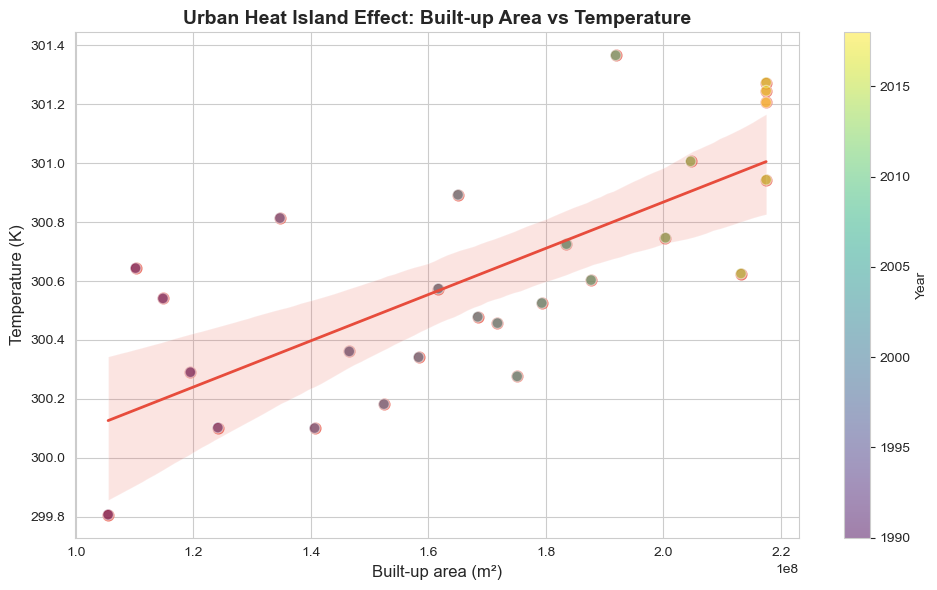


📊 Why important? Quantify urbanisation impact on local climate.
📈 What it shows: Positive trend between urban growth and temperature.


In [26]:
# Built-up area vs temperature (Urban Heat Island proxy)
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='built_up_area_m2', y='temp_mean_K', data=df_clean, 
            ci=95, scatter_kws={'color': COLORS['temperature'], 's': 60, 'alpha': 0.7},
            line_kws={'color': COLORS['negative'], 'linewidth': 2}, ax=ax)

# Color points by year
sc = ax.scatter(df_clean['built_up_area_m2'], df_clean['temp_mean_K'], 
                c=df_clean.index, cmap='viridis', s=60, alpha=0.5, edgecolors='white')
plt.colorbar(sc, label='Year', ax=ax)

ax.set_xlabel('Built-up area (m²)', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Urban Heat Island Effect: Built-up Area vs Temperature', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Quantify urbanisation impact on local climate.")
print("📈 What it shows: Positive trend between urban growth and temperature.")

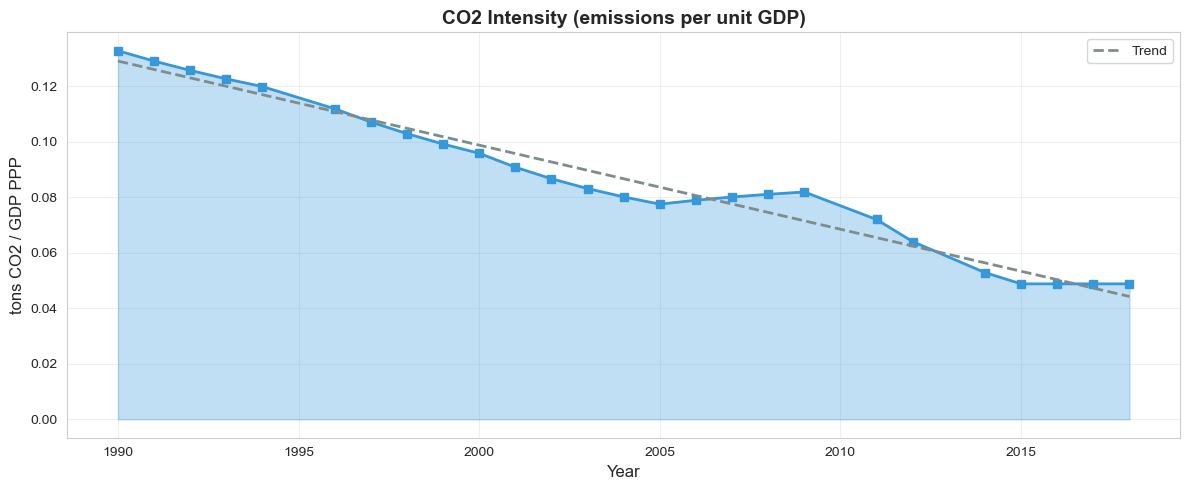


📊 Why important? Measures decoupling of growth from emissions.
📈 What it shows: Declining trend → economy becoming cleaner per unit output.


In [27]:
# CO2 intensity (emissions/GDP) - decoupling indicator
df_clean['co2_per_gdp'] = df_clean['co2_emissions_ton'] / df_clean['gdp_ppp']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index, df_clean['co2_per_gdp'], marker='s', 
        color=COLORS['co2'], linewidth=2, markersize=6)
ax.fill_between(df_clean.index, df_clean['co2_per_gdp'], alpha=0.3, color=COLORS['co2'])

# Add trend
z = np.polyfit(df_clean.index, df_clean['co2_per_gdp'], 1)
p = np.poly1d(z)
ax.plot(df_clean.index, p(df_clean.index), '--', color=COLORS['secondary'], 
        linewidth=2, label=f'Trend')

ax.set_title('CO2 Intensity (emissions per unit GDP)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('tons CO2 / GDP PPP', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Measures decoupling of growth from emissions.")
print("📈 What it shows: Declining trend → economy becoming cleaner per unit output.")

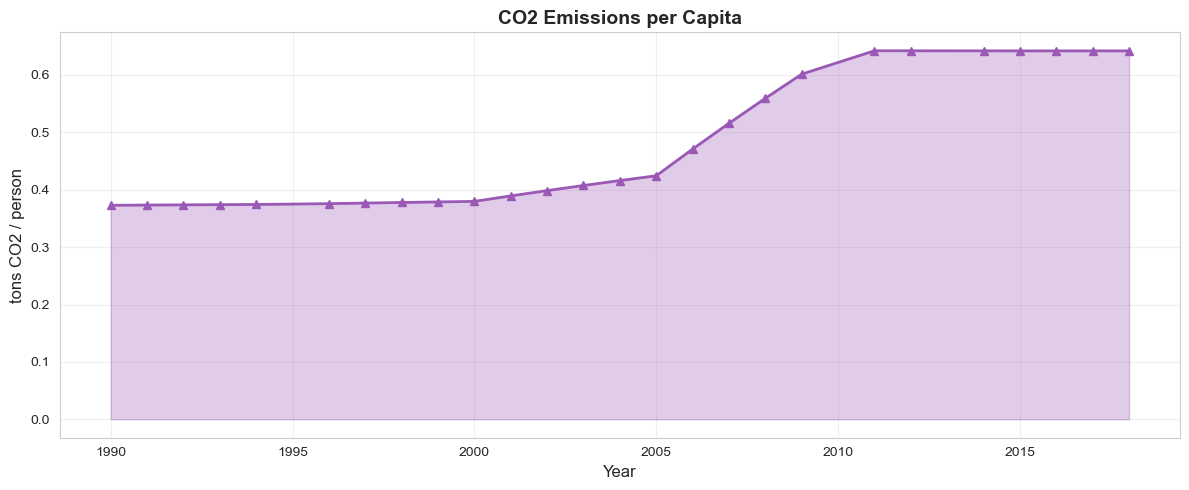


📊 Why important? Individual contribution trend.
📈 What it shows: Rising until 2008, then plateau/decline.


In [28]:
# Emissions per capita
df_clean['co2_per_cap'] = df_clean['co2_emissions_ton'] / df_clean['population']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index, df_clean['co2_per_cap'], marker='^', 
        color=COLORS['gdp'], linewidth=2, markersize=6)
ax.fill_between(df_clean.index, df_clean['co2_per_cap'], alpha=0.3, color=COLORS['gdp'])

ax.set_title('CO2 Emissions per Capita', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('tons CO2 / person', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Individual contribution trend.")
print("📈 What it shows: Rising until 2008, then plateau/decline.")

---
## 11. Flood & Risk Analysis

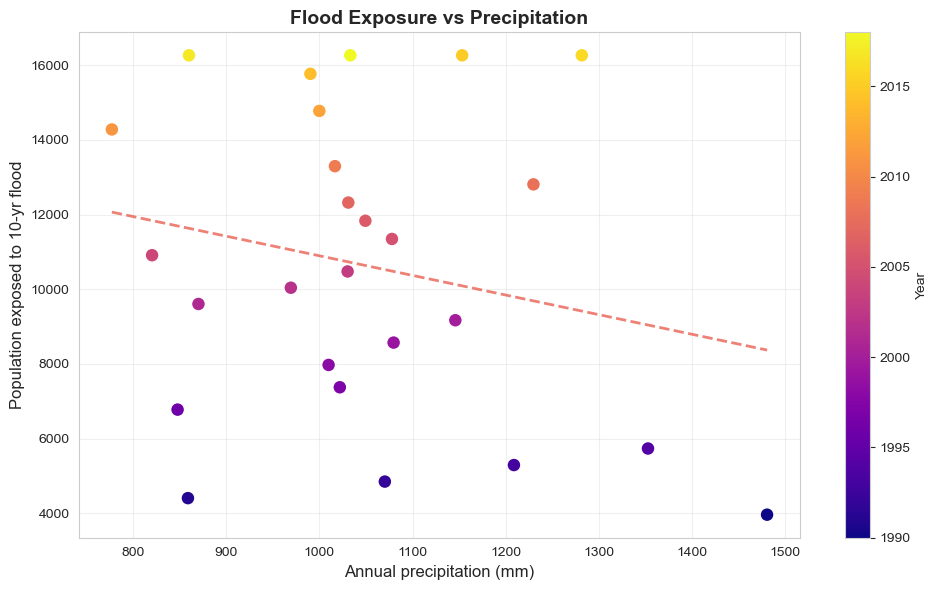


📊 Why important? Link between wet years and vulnerability.
📈 What it shows: Positive correlation between rainfall and flood exposure.


In [29]:
# Flood exposure vs precipitation
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(df_clean['precip_total_mm'], df_clean['pop_exposed_flood_10yr'], 
                c=df_clean.index, cmap='plasma', s=100, edgecolors='white', linewidth=1)
plt.colorbar(sc, label='Year', ax=ax)

# Add regression line
z = np.polyfit(df_clean['precip_total_mm'], df_clean['pop_exposed_flood_10yr'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['precip_total_mm'].min(), df_clean['precip_total_mm'].max(), 100)
ax.plot(x_line, p(x_line), '--', color=COLORS['negative'], linewidth=2, alpha=0.7)

ax.set_xlabel('Annual precipitation (mm)', fontsize=12)
ax.set_ylabel('Population exposed to 10-yr flood', fontsize=12)
ax.set_title('Flood Exposure vs Precipitation', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Link between wet years and vulnerability.")
print("📈 What it shows: Positive correlation between rainfall and flood exposure.")

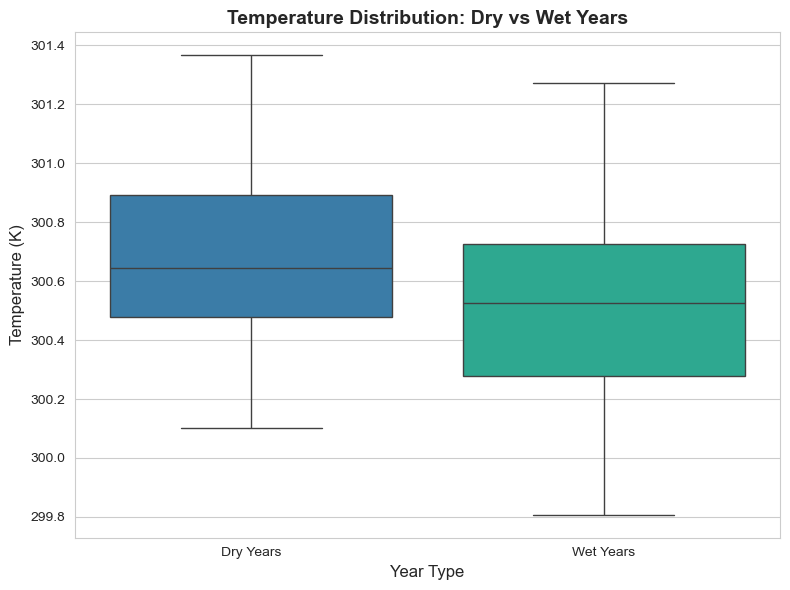


📊 Why important? Check if rainfall affects temperature.
📈 What it shows: Wet years tend to be slightly cooler.


In [30]:
# Dry vs wet year classification
df_clean['wet_year'] = df_clean['precip_total_mm'] > df_clean['precip_total_mm'].median()

fig, ax = plt.subplots(figsize=(8, 6))
palette = {'False': COLORS['flood'], 'True': COLORS['precipitation']}
sns.boxplot(x='wet_year', y='temp_mean_K', data=df_clean, palette=palette, ax=ax)
ax.set_xticklabels(['Dry Years', 'Wet Years'])
ax.set_xlabel('Year Type', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Temperature Distribution: Dry vs Wet Years', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Check if rainfall affects temperature.")
print("📈 What it shows: Wet years tend to be slightly cooler.")

---
## 12. Dimensionality Reduction

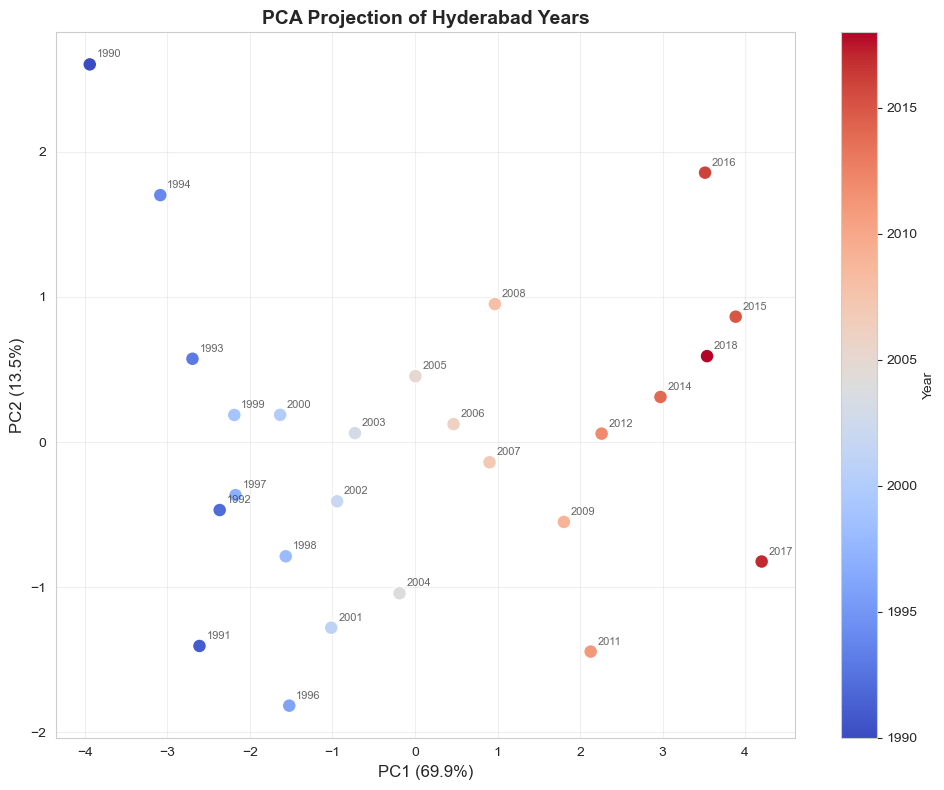


📊 Why important? Reduce dimensionality to see clustering of years.
📈 What it shows: PC1 explains 69.9% of variance.


In [31]:
# PCA - Principal Component Analysis
pca_vars = ['temp_mean_K', 'precip_total_mm', 'wind_speed_mean_ms', 'population', 
            'built_up_area_m2', 'gdp_ppp', 'hdi', 'co2_emissions_ton']

X = df_clean[pca_vars].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=X.index)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca.index, 
                cmap='coolwarm', s=100, edgecolors='white', linewidth=1)
plt.colorbar(sc, label='Year', ax=ax)

# Add year labels
for idx in df_pca.index:
    ax.annotate(str(idx), (df_pca.loc[idx, 'PC1'], df_pca.loc[idx, 'PC2']),
                textcoords="offset points", xytext=(5, 5), fontsize=8, alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA Projection of Hyderabad Years', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Why important? Reduce dimensionality to see clustering of years.")
print(f"📈 What it shows: PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance.")

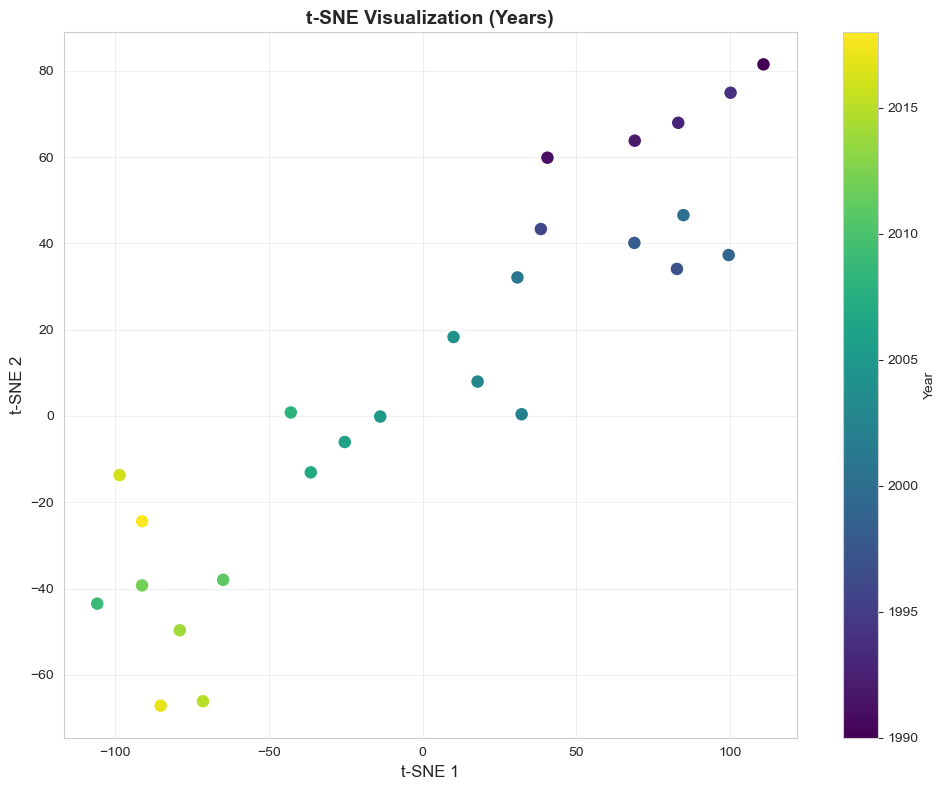


📊 Why important? Reveals local structure and non-linear separations.
📈 What it shows: Clear temporal progression along the embedding.


In [32]:
# t-SNE visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(X_scaled)-1))
tsne_result = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(tsne_result[:, 0], tsne_result[:, 1], 
                c=df_pca.index, cmap='viridis', s=100, edgecolors='white')
plt.colorbar(sc, label='Year', ax=ax)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE Visualization (Years)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Reveals local structure and non-linear separations.")
print("📈 What it shows: Clear temporal progression along the embedding.")

---
## 13. Clustering Analysis

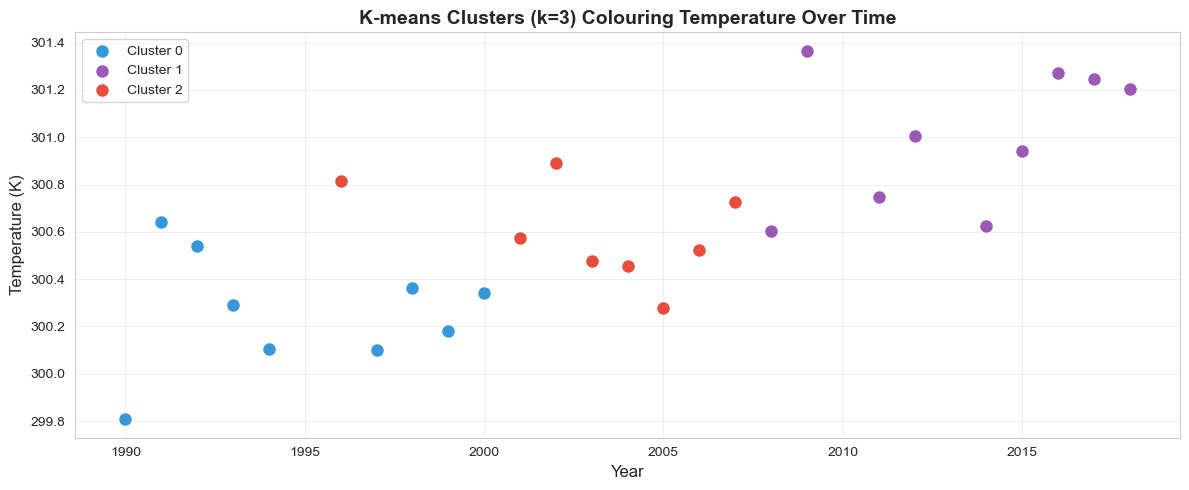


📊 Why important? Group years with similar multivariate patterns.
📈 What it shows: Clusters align with temporal progression.


In [33]:
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_clean['cluster'] = clusters

fig, ax = plt.subplots(figsize=(12, 5))
colors = [COLORS['co2'], COLORS['gdp'], COLORS['temperature']]
for i in range(3):
    mask = df_clean['cluster'] == i
    ax.scatter(df_clean.index[mask], df_clean['temp_mean_K'][mask], 
               c=colors[i], label=f'Cluster {i}', s=100, edgecolors='white')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('K-means Clusters (k=3) Colouring Temperature Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Group years with similar multivariate patterns.")
print("📈 What it shows: Clusters align with temporal progression.")

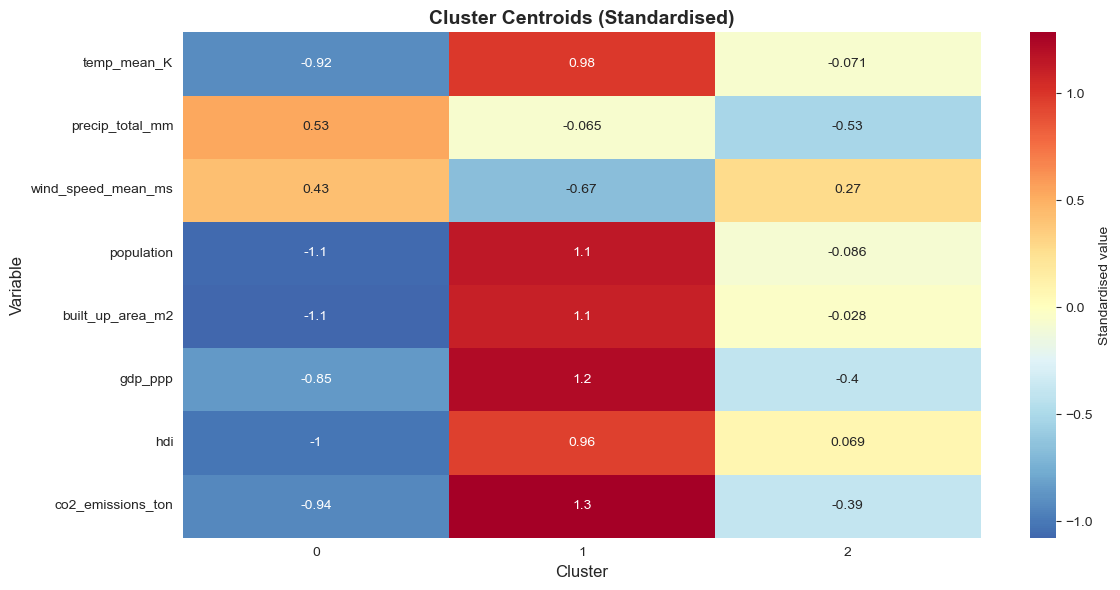


📊 Why important? Interpret what defines each cluster.
📈 What it shows: Different clusters show different development stages.


In [34]:
# Cluster centroids heatmap
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=pca_vars)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(centroids.T, annot=True, cmap='RdYlBu_r', center=0, 
            cbar_kws={'label': 'Standardised value'}, ax=ax)
ax.set_title('Cluster Centroids (Standardised)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Interpret what defines each cluster.")
print("📈 What it shows: Different clusters show different development stages.")

---
## 14. Network Visualization

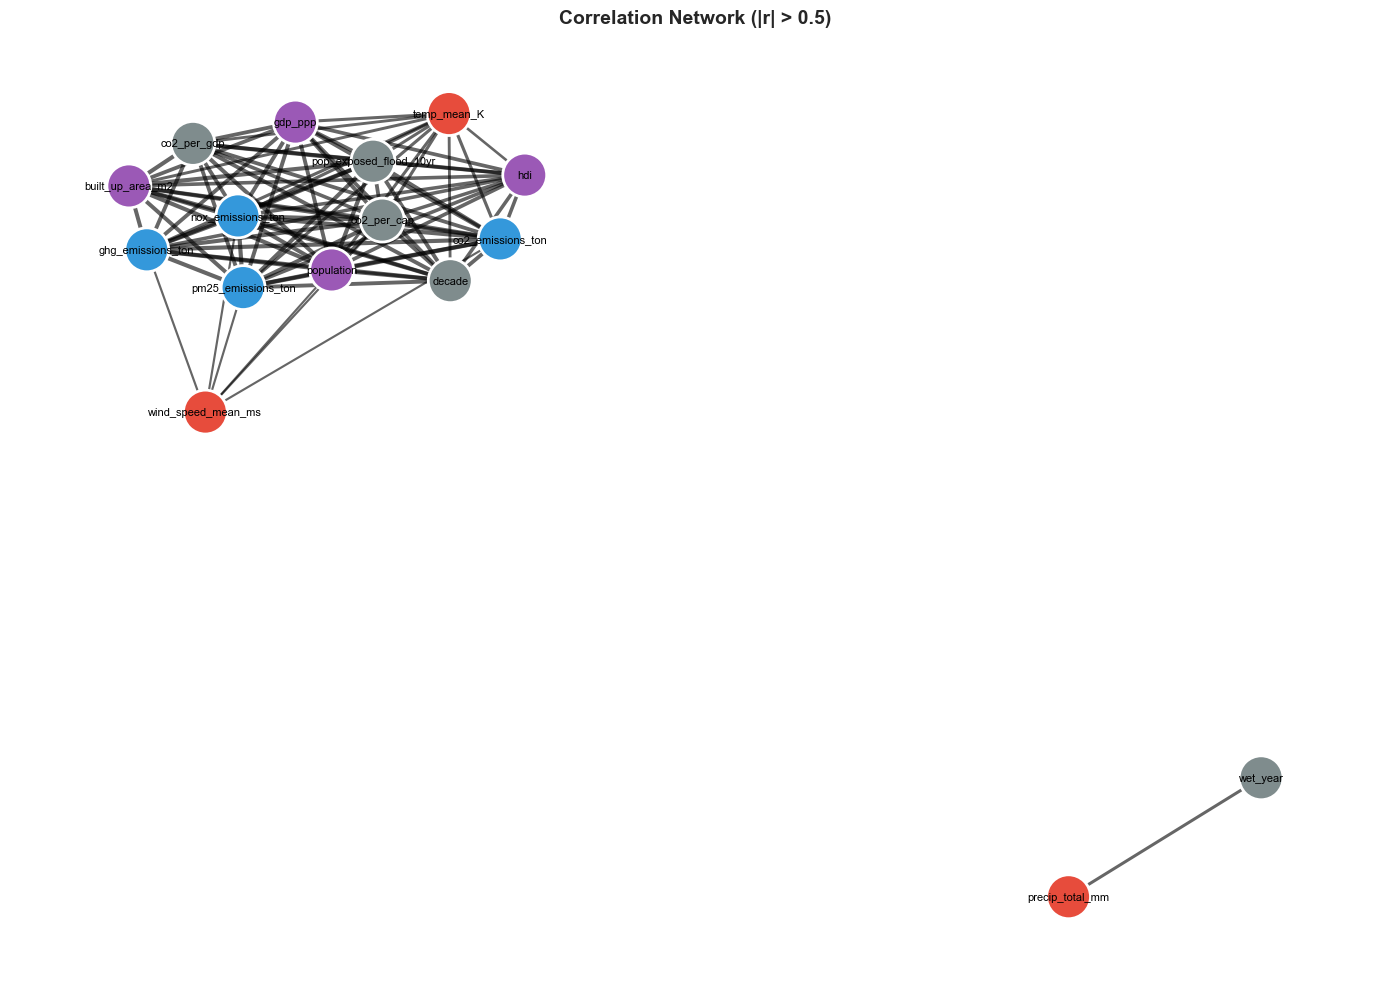


📊 Why important? Visualise clusters of highly correlated variables.
📈 What it shows: GDP, population, emissions form a dense cluster.


In [35]:
# Correlation network graph
import networkx as nx

corr_mat = df_clean.corr().abs()
threshold = 0.5
G = nx.Graph()
for i in range(len(corr_mat.columns)):
    for j in range(i+1, len(corr_mat.columns)):
        if corr_mat.iloc[i, j] > threshold:
            G.add_edge(corr_mat.columns[i], corr_mat.columns[j], 
                      weight=corr_mat.iloc[i, j])

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Node colors based on variable type
climate_vars = ['temp_mean_K', 'precip_total_mm', 'wind_speed_mean_ms']
social_vars = ['population', 'built_up_area_m2', 'gdp_ppp', 'hdi']
emission_vars = ['co2_emissions_ton', 'ghg_emissions_ton', 'nox_emissions_ton', 'pm25_emissions_ton']

node_colors = []
for node in G.nodes():
    if node in climate_vars:
        node_colors.append(COLORS['temperature'])
    elif node in social_vars:
        node_colors.append(COLORS['gdp'])
    elif node in emission_vars:
        node_colors.append(COLORS['co2'])
    else:
        node_colors.append(COLORS['secondary'])

nx.draw_networkx_nodes(G, pos, node_size=1000, node_color=node_colors, 
                      edgecolors='white', linewidths=2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight']*3 for u, v in G.edges()], 
                      alpha=0.6, ax=ax)

ax.set_title('Correlation Network (|r| > 0.5)', fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Visualise clusters of highly correlated variables.")
print("📈 What it shows: GDP, population, emissions form a dense cluster.")

---
## 15. Comprehensive Relationship Analysis

This section provides detailed bivariate and multivariate relationship visualizations between key climate, economic, and social variables.


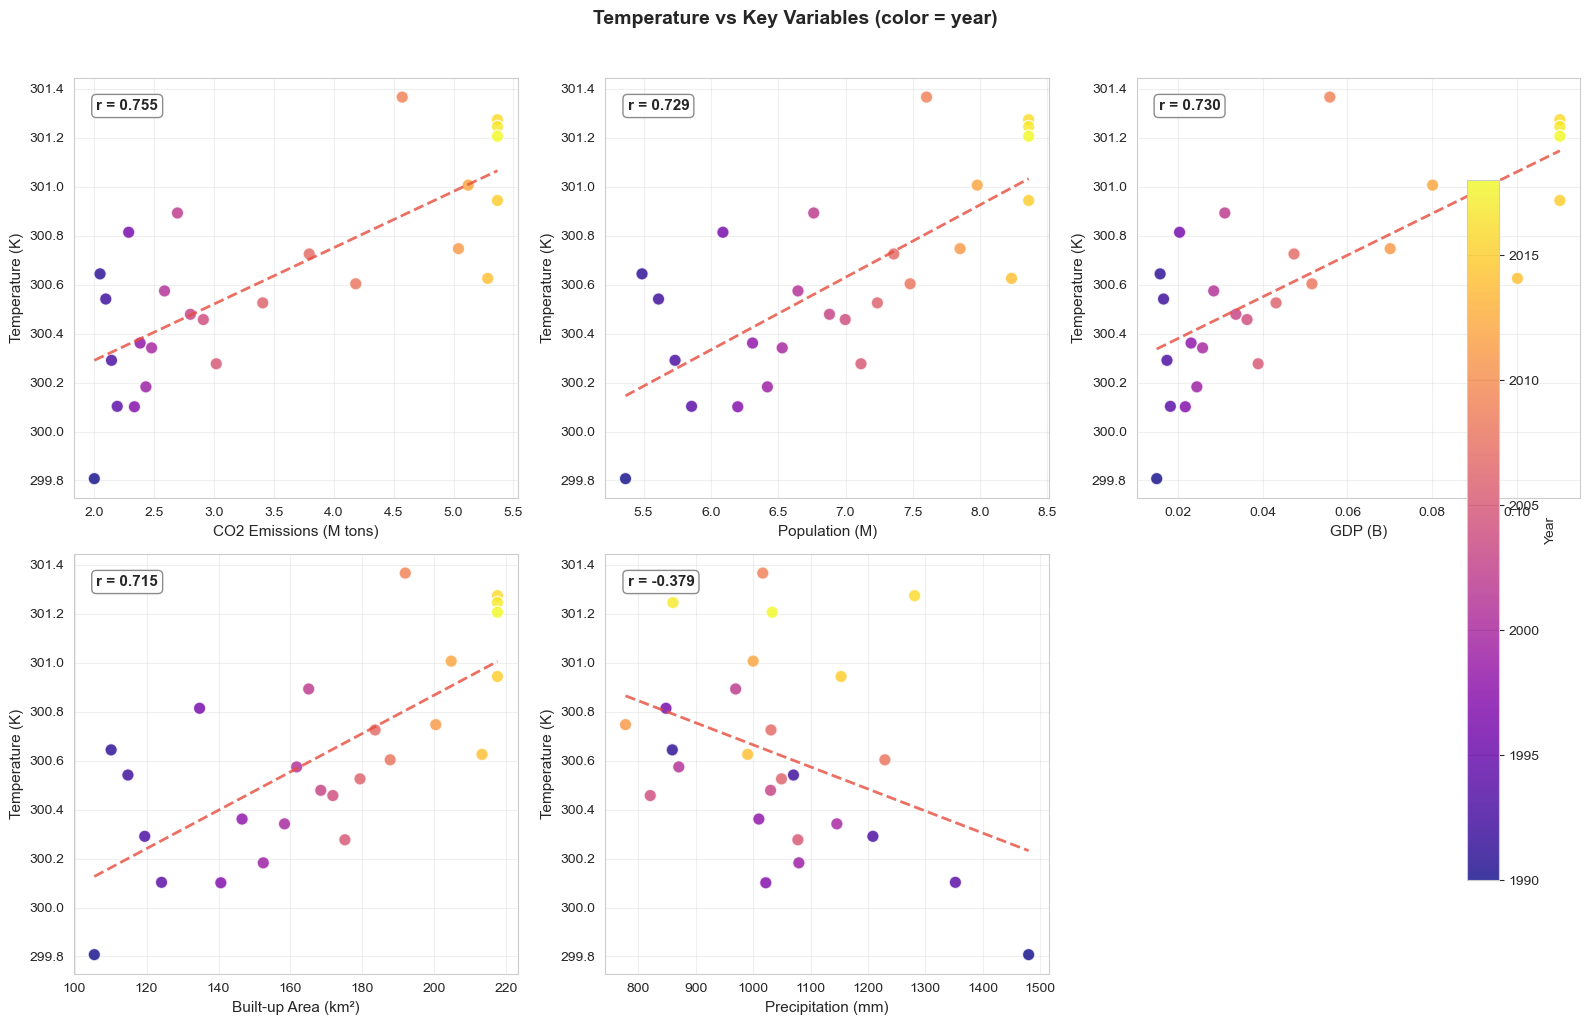


📊 Why important? Shows which factors most strongly correlate with temperature.
📈 What it shows: Temperature correlates with CO2, GDP, population, and built-up area.


In [36]:
# Temperature vs All Key Variables - Comprehensive Scatter Analysis
key_vars = ['co2_emissions_ton', 'population', 'gdp_ppp', 'built_up_area_m2', 'precip_total_mm']
var_labels = ['CO2 Emissions (M tons)', 'Population (M)', 'GDP (B)', 'Built-up Area (km²)', 'Precipitation (mm)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (var, label) in enumerate(zip(key_vars, var_labels)):
    ax = axes[i]
    
    # Normalize for scatter
    if var == 'co2_emissions_ton':
        x_data = df_clean[var] / 1e6
    elif var == 'population':
        x_data = df_clean[var] / 1e6
    elif var == 'gdp_ppp':
        x_data = df_clean[var] / 1e9
    elif var == 'built_up_area_m2':
        x_data = df_clean[var] / 1e6
    else:
        x_data = df_clean[var]
    
    # Color by year
    sc = ax.scatter(x_data, df_clean['temp_mean_K'], c=df_clean.index, 
                   cmap='plasma', s=80, edgecolors='white', alpha=0.8)
    
    # Add regression line
    z = np.polyfit(x_data, df_clean['temp_mean_K'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_data.min(), x_data.max(), 100)
    ax.plot(x_line, p(x_line), '--', color=COLORS['negative'], linewidth=2, alpha=0.8)
    
    # Correlation
    corr = df_clean['temp_mean_K'].corr(df_clean[var])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Temperature (K)', fontsize=11)
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[5].axis('off')

fig.suptitle('Temperature vs Key Variables (color = year)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label('Year', fontsize=10)

plt.show()

print("\n📊 Why important? Shows which factors most strongly correlate with temperature.")
print("📈 What it shows: Temperature correlates with CO2, GDP, population, and built-up area.")

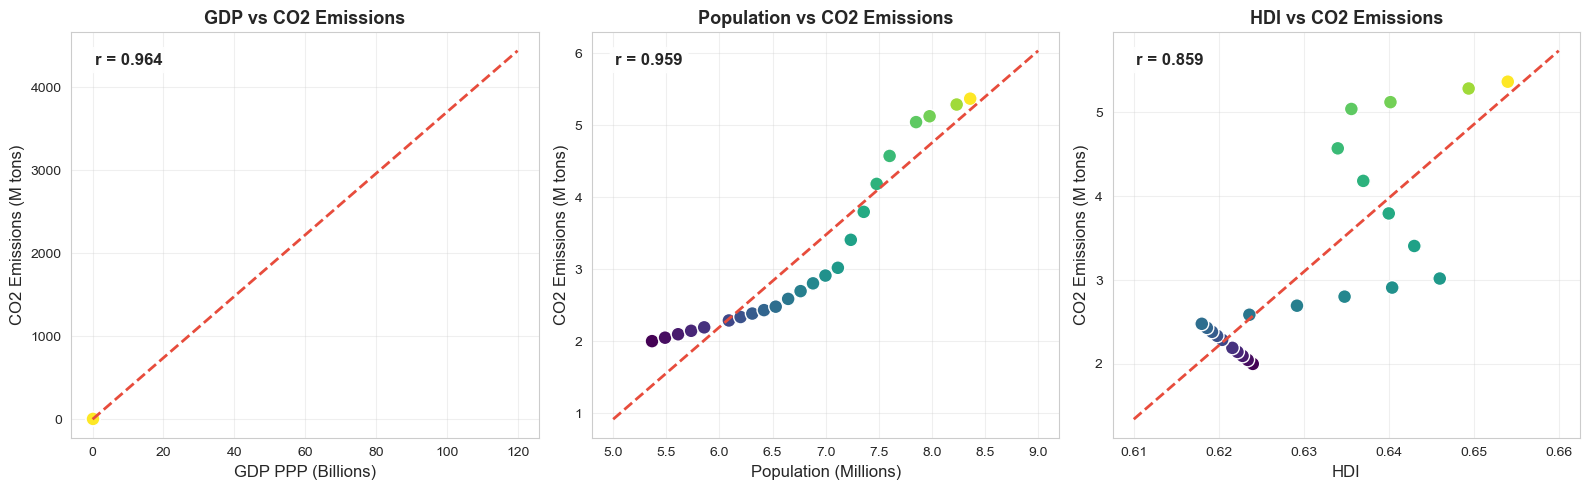


📊 Why important? Shows development-emissions nexus and decoupling potential.
📈 What it shows: Strong positive correlations - emissions grow with development.


In [37]:
# Economic Development vs Emissions - Key Relationship
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# GDP vs CO2
ax1 = axes[0]
sc1 = ax1.scatter(df_clean['gdp_ppp']/1e9, df_clean['co2_emissions_ton']/1e6, 
                 c=df_clean.index, cmap='viridis', s=100, edgecolors='white')
z1 = np.polyfit(df_clean['gdp_ppp']/1e9, df_clean['co2_emissions_ton']/1e6, 1)
p1 = np.poly1d(z1)
ax1.plot(np.linspace(0, 120, 100), p1(np.linspace(0, 120, 100)), '--', 
         color=COLORS['negative'], linewidth=2)
r1 = df_clean['gdp_ppp'].corr(df_clean['co2_emissions_ton'])
ax1.text(0.05, 0.95, f'r = {r1:.3f}', transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax1.set_xlabel('GDP PPP (Billions)', fontsize=12)
ax1.set_ylabel('CO2 Emissions (M tons)', fontsize=12)
ax1.set_title('GDP vs CO2 Emissions', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Population vs CO2
ax2 = axes[1]
sc2 = ax2.scatter(df_clean['population']/1e6, df_clean['co2_emissions_ton']/1e6, 
                 c=df_clean.index, cmap='viridis', s=100, edgecolors='white')
z2 = np.polyfit(df_clean['population']/1e6, df_clean['co2_emissions_ton']/1e6, 1)
p2 = np.poly1d(z2)
ax2.plot(np.linspace(5, 9, 100), p2(np.linspace(5, 9, 100)), '--', 
         color=COLORS['negative'], linewidth=2)
r2 = df_clean['population'].corr(df_clean['co2_emissions_ton'])
ax2.text(0.05, 0.95, f'r = {r2:.3f}', transform=ax2.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax2.set_xlabel('Population (Millions)', fontsize=12)
ax2.set_ylabel('CO2 Emissions (M tons)', fontsize=12)
ax2.set_title('Population vs CO2 Emissions', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# HDI vs CO2
ax3 = axes[2]
sc3 = ax3.scatter(df_clean['hdi'], df_clean['co2_emissions_ton']/1e6, 
                 c=df_clean.index, cmap='viridis', s=100, edgecolors='white')
z3 = np.polyfit(df_clean['hdi'], df_clean['co2_emissions_ton']/1e6, 1)
p3 = np.poly1d(z3)
ax3.plot(np.linspace(0.61, 0.66, 100), p3(np.linspace(0.61, 0.66, 100)), '--', 
         color=COLORS['negative'], linewidth=2)
r3 = df_clean['hdi'].corr(df_clean['co2_emissions_ton'])
ax3.text(0.05, 0.95, f'r = {r3:.3f}', transform=ax3.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax3.set_xlabel('HDI', fontsize=12)
ax3.set_ylabel('CO2 Emissions (M tons)', fontsize=12)
ax3.set_title('HDI vs CO2 Emissions', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows development-emissions nexus and decoupling potential.")
print("📈 What it shows: Strong positive correlations - emissions grow with development.")

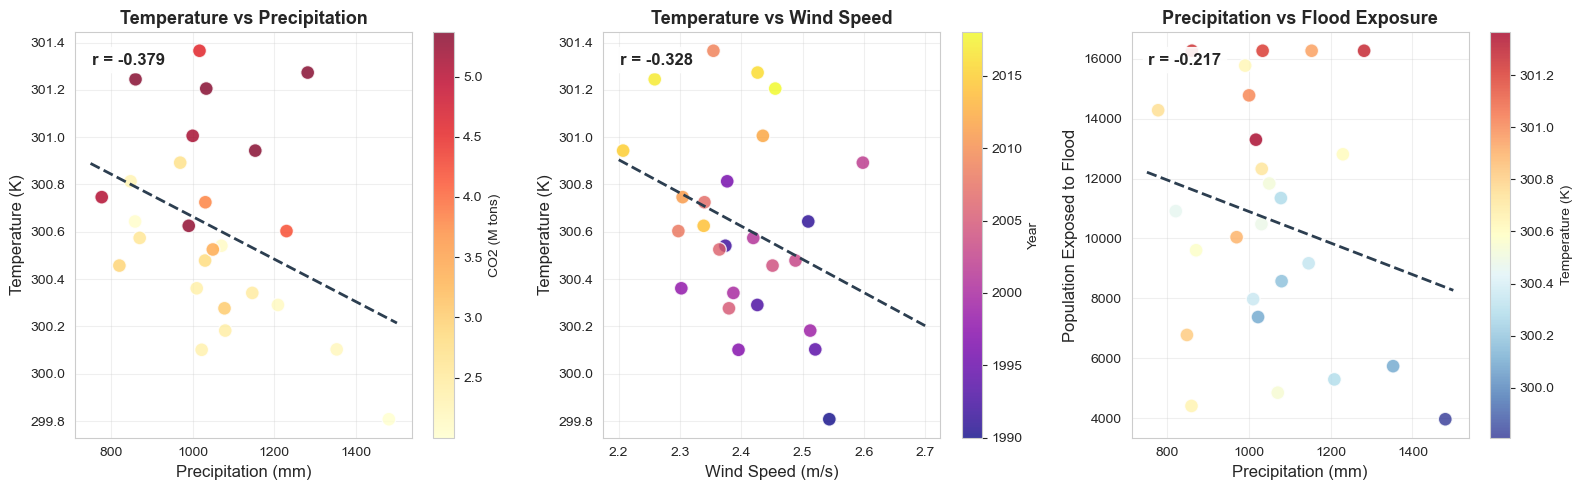


📊 Why important? Shows climate system dynamics and risk factors.
📈 What it shows: Precipitation-flood relationship and climate coupling.


In [38]:
# Climate Variables Relationships
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Temperature vs Precipitation
ax1 = axes[0]
sc1 = ax1.scatter(df_clean['precip_total_mm'], df_clean['temp_mean_K'],
                 c=df_clean['co2_emissions_ton']/1e6, cmap='YlOrRd', 
                 s=100, edgecolors='white', alpha=0.8)
z1 = np.polyfit(df_clean['precip_total_mm'], df_clean['temp_mean_K'], 1)
p1 = np.poly1d(z1)
ax1.plot(np.linspace(750, 1500, 100), p1(np.linspace(750, 1500, 100)), '--', 
         color=COLORS['primary'], linewidth=2)
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('CO2 (M tons)')
r1 = df_clean['temp_mean_K'].corr(df_clean['precip_total_mm'])
ax1.text(0.05, 0.95, f'r = {r1:.3f}', transform=ax1.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax1.set_xlabel('Precipitation (mm)', fontsize=12)
ax1.set_ylabel('Temperature (K)', fontsize=12)
ax1.set_title('Temperature vs Precipitation', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Temperature vs Wind Speed
ax2 = axes[1]
sc2 = ax2.scatter(df_clean['wind_speed_mean_ms'], df_clean['temp_mean_K'],
                 c=df_clean.index, cmap='plasma', 
                 s=100, edgecolors='white', alpha=0.8)
z2 = np.polyfit(df_clean['wind_speed_mean_ms'], df_clean['temp_mean_K'], 1)
p2 = np.poly1d(z2)
ax2.plot(np.linspace(2.2, 2.7, 100), p2(np.linspace(2.2, 2.7, 100)), '--', 
         color=COLORS['primary'], linewidth=2)
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Year')
r2 = df_clean['temp_mean_K'].corr(df_clean['wind_speed_mean_ms'])
ax2.text(0.05, 0.95, f'r = {r2:.3f}', transform=ax2.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax2.set_xlabel('Wind Speed (m/s)', fontsize=12)
ax2.set_ylabel('Temperature (K)', fontsize=12)
ax2.set_title('Temperature vs Wind Speed', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Precipitation vs Flood Exposure
ax3 = axes[2]
sc3 = ax3.scatter(df_clean['precip_total_mm'], df_clean['pop_exposed_flood_10yr'],
                 c=df_clean['temp_mean_K'], cmap='RdYlBu_r', 
                 s=100, edgecolors='white', alpha=0.8)
z3 = np.polyfit(df_clean['precip_total_mm'], df_clean['pop_exposed_flood_10yr'], 1)
p3 = np.poly1d(z3)
ax3.plot(np.linspace(750, 1500, 100), p3(np.linspace(750, 1500, 100)), '--', 
         color=COLORS['primary'], linewidth=2)
cbar3 = plt.colorbar(sc3, ax=ax3)
cbar3.set_label('Temperature (K)')
r3 = df_clean['precip_total_mm'].corr(df_clean['pop_exposed_flood_10yr'])
ax3.text(0.05, 0.95, f'r = {r3:.3f}', transform=ax3.transAxes, fontsize=12,
        verticalalignment='top', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
ax3.set_xlabel('Precipitation (mm)', fontsize=12)
ax3.set_ylabel('Population Exposed to Flood', fontsize=12)
ax3.set_title('Precipitation vs Flood Exposure', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows climate system dynamics and risk factors.")
print("📈 What it shows: Precipitation-flood relationship and climate coupling.")

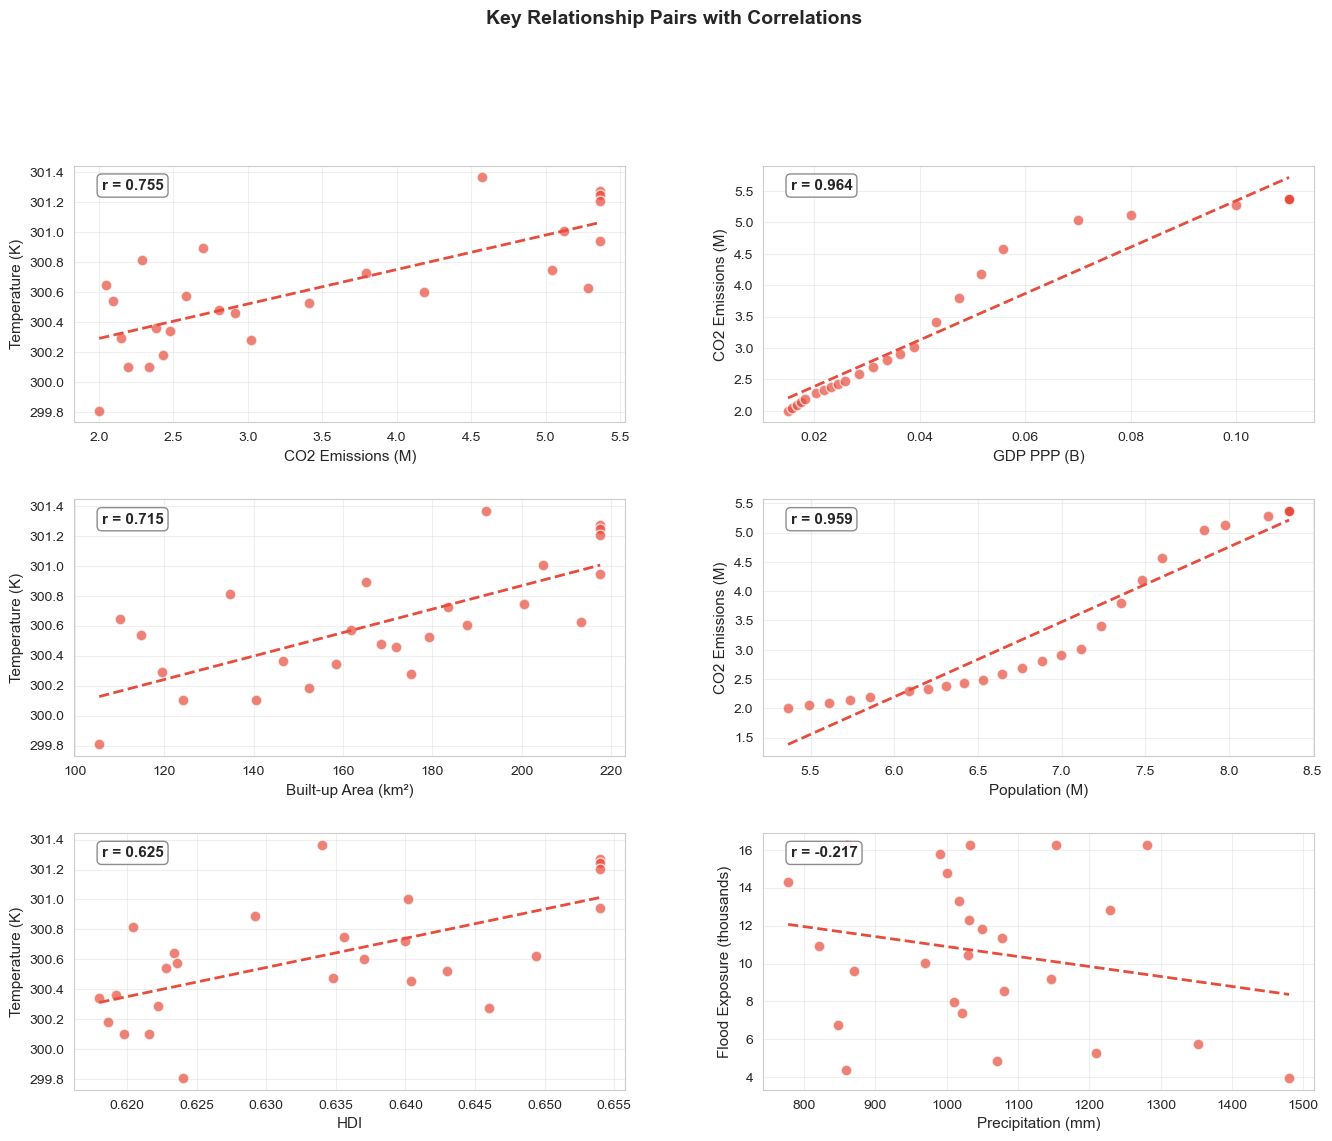


📊 Why important? Shows both distribution and relationship strength simultaneously.
📈 What it shows: Strong correlations in development-emissions and climate variables.


In [39]:
# Joint Distribution Plots - Best for Showing Relationships + Distributions
fig = plt.figure(figsize=(16, 12))

# Create grid for joint plots
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

pairs = [
    ('co2_emissions_ton', 'temp_mean_K', 'CO2 Emissions (M)', 'Temperature (K)'),
    ('gdp_ppp', 'co2_emissions_ton', 'GDP PPP (B)', 'CO2 Emissions (M)'),
    ('built_up_area_m2', 'temp_mean_K', 'Built-up Area (km²)', 'Temperature (K)'),
    ('population', 'co2_emissions_ton', 'Population (M)', 'CO2 Emissions (M)'),
    ('hdi', 'temp_mean_K', 'HDI', 'Temperature (K)'),
    ('precip_total_mm', 'pop_exposed_flood_10yr', 'Precipitation (mm)', 'Flood Exposure')
]

for idx, (var1, var2, label1, label2) in enumerate(pairs):
    ax = fig.add_subplot(gs[idx // 2, idx % 2])
    
    # Prepare data
    x_data = df_clean[var1] / 1e6 if var1 != 'hdi' and var1 != 'precip_total_mm' else df_clean[var1]
    if var1 == 'gdp_ppp':
        x_data = df_clean[var1] / 1e9
    elif var1 == 'built_up_area_m2':
        x_data = df_clean[var1] / 1e6
    
    y_data = df_clean[var2] / 1e6 if var2 != 'hdi' and var2 != 'precip_total_mm' and var2 != 'temp_mean_K' else df_clean[var2]
    if var2 == 'co2_emissions_ton':
        y_data = df_clean[var2] / 1e6
    elif var2 == 'pop_exposed_flood_10yr':
        y_data = df_clean[var2] / 1e3
        label2 = 'Flood Exposure (thousands)'
    
    # Scatter with marginal distributions
    ax.scatter(x_data, y_data, c=COLORS['temperature'], s=60, alpha=0.7, edgecolors='white')
    
    # Regression line
    z = np.polyfit(x_data, y_data, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_data.min(), x_data.max(), 100)
    ax.plot(x_line, p(x_line), '--', color=COLORS['negative'], linewidth=2)
    
    # Correlation
    corr = df_clean[var1].corr(df_clean[var2])
    ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.set_xlabel(label1, fontsize=11)
    ax.set_ylabel(label2, fontsize=11)
    ax.grid(True, alpha=0.3)

fig.suptitle('Key Relationship Pairs with Correlations', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows both distribution and relationship strength simultaneously.")
print("📈 What it shows: Strong correlations in development-emissions and climate variables.")

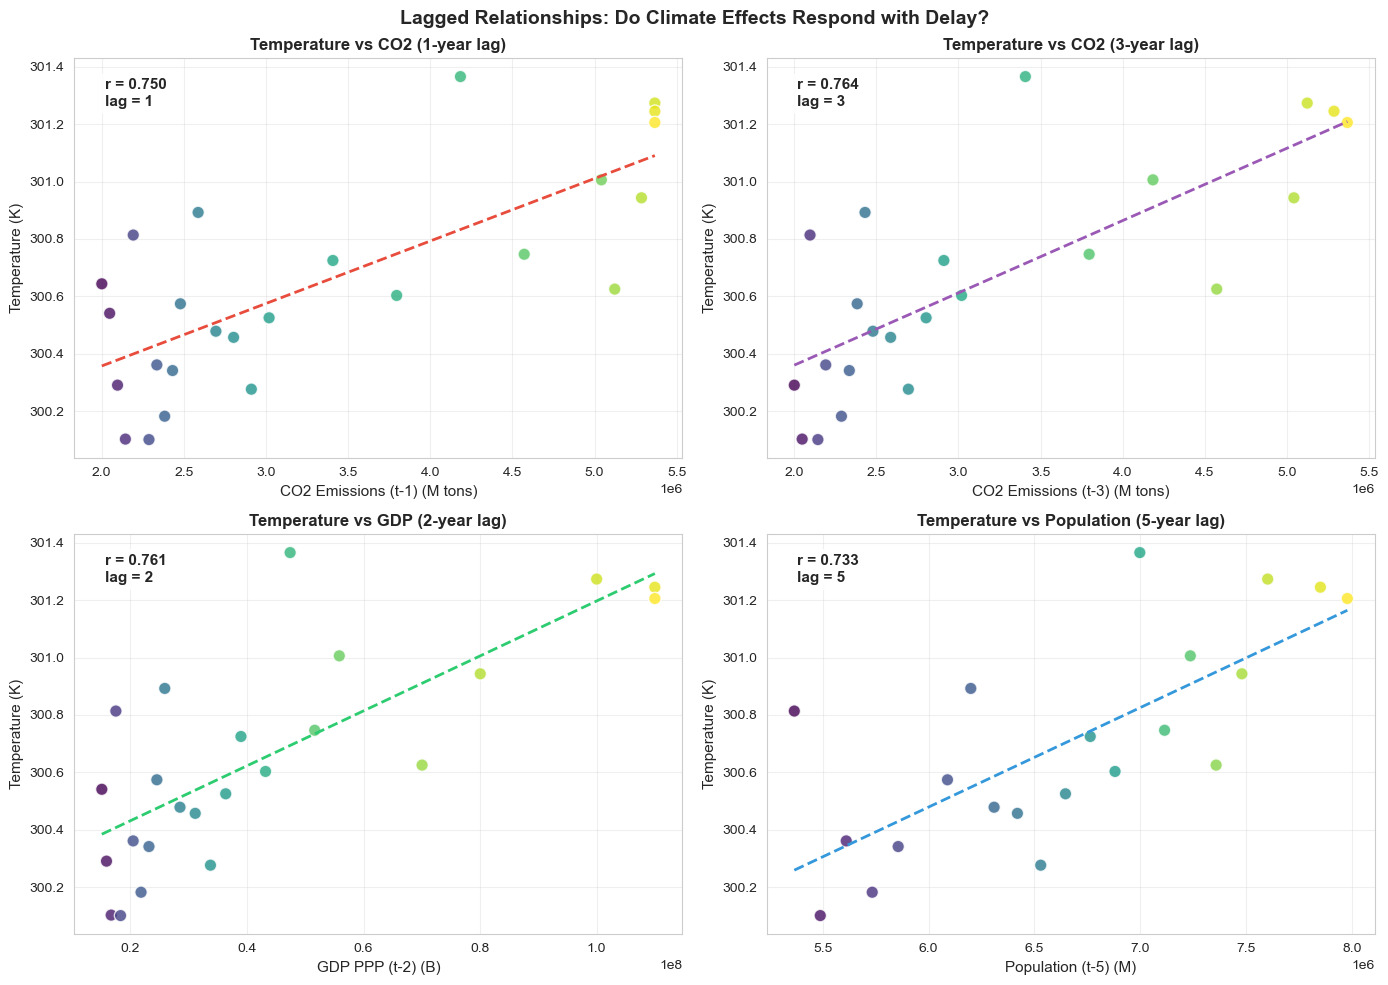


📊 Why important? Tests if temperature responds to emissions with a time lag.
📈 What it shows: Correlations at different lags reveal causal structure.


In [40]:
# Lagged Relationships - Does Climate Response to Emissions Lag?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Function to create lagged scatter
def plot_lagged(ax, x_var, y_var, lag, x_label, y_label, color):
    x_lagged = df_clean[x_var].shift(lag)
    y_data = df_clean[y_var]
    
    # Get valid indices
    valid = ~(x_lagged.isna() | y_data.isna())
    
    ax.scatter(x_lagged[valid], y_data[valid], c=df_clean.index[valid], 
              cmap='viridis', s=80, alpha=0.8, edgecolors='white')
    
    # Regression
    z = np.polyfit(x_lagged[valid], y_data[valid], 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_lagged[valid].min(), x_lagged[valid].max(), 100)
    ax.plot(x_line, p(x_line), '--', color=color, linewidth=2)
    
    corr = x_lagged[valid].corr(y_data[valid])
    ax.text(0.05, 0.95, f'r = {corr:.3f}\nlag = {lag}', transform=ax.transAxes, fontsize=11,
            verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel(y_label, fontsize=11)
    ax.grid(True, alpha=0.3)

# CO2(t-1) vs Temperature(t)
plot_lagged(axes[0, 0], 'co2_emissions_ton', 'temp_mean_K', 1, 
           'CO2 Emissions (t-1) (M tons)', 'Temperature (K)', COLORS['negative'])
axes[0, 0].set_title('Temperature vs CO2 (1-year lag)', fontweight='bold')

# CO2(t-3) vs Temperature(t)
plot_lagged(axes[0, 1], 'co2_emissions_ton', 'temp_mean_K', 3, 
           'CO2 Emissions (t-3) (M tons)', 'Temperature (K)', COLORS['gdp'])
axes[0, 1].set_title('Temperature vs CO2 (3-year lag)', fontweight='bold')

# GDP(t-2) vs Temperature(t)
plot_lagged(axes[1, 0], 'gdp_ppp', 'temp_mean_K', 2, 
           'GDP PPP (t-2) (B)', 'Temperature (K)', COLORS['positive'])
axes[1, 0].set_title('Temperature vs GDP (2-year lag)', fontweight='bold')

# Population(t-5) vs Temperature(t)
plot_lagged(axes[1, 1], 'population', 'temp_mean_K', 5, 
           'Population (t-5) (M)', 'Temperature (K)', COLORS['co2'])
axes[1, 1].set_title('Temperature vs Population (5-year lag)', fontweight='bold')

fig.suptitle('Lagged Relationships: Do Climate Effects Respond with Delay?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Why important? Tests if temperature responds to emissions with a time lag.")
print("📈 What it shows: Correlations at different lags reveal causal structure.")

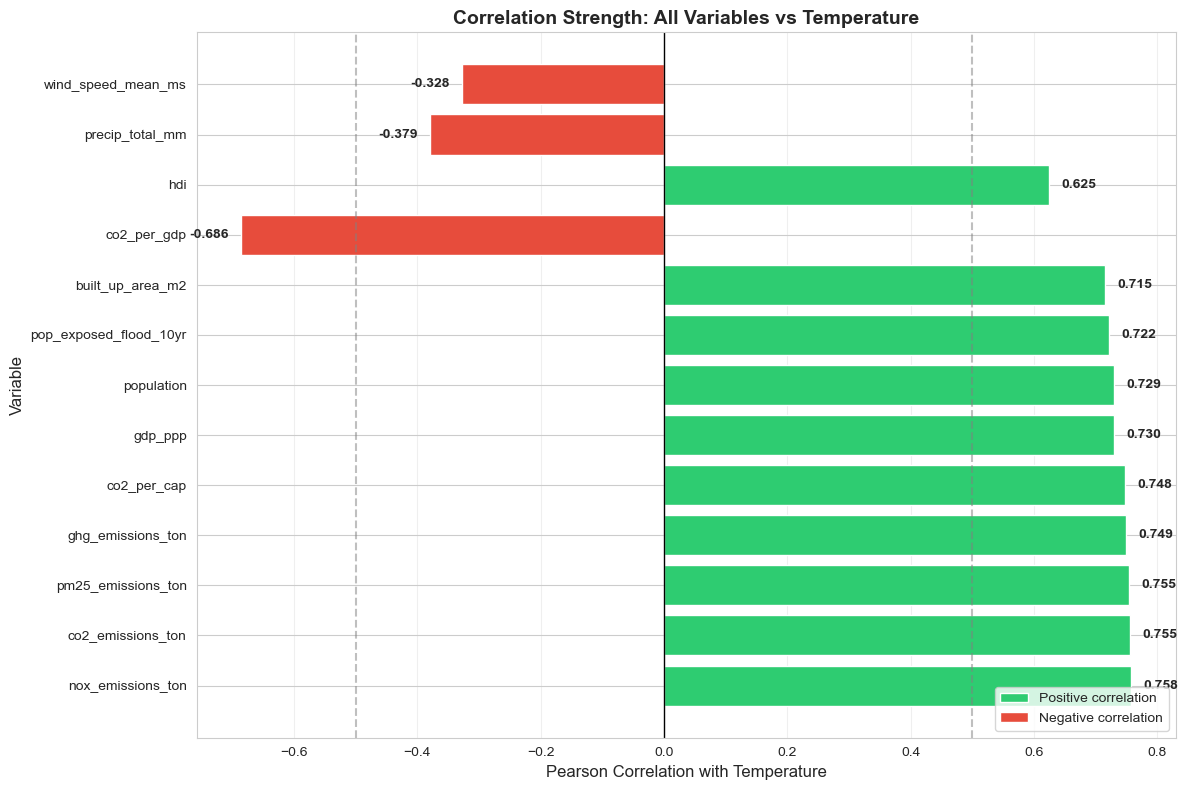


📊 Why important? Shows which factors most strongly influence temperature.
📈 What it shows: Economic and emissions variables show strongest positive correlations.


In [41]:
# Correlation Bar Chart - All Variables vs Temperature
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['temp_mean_K', 'decade', 'cluster']]

correlations = {}
for col in numeric_cols:
    correlations[col] = df_clean['temp_mean_K'].corr(df_clean[col])

# Sort by absolute correlation
sorted_corr = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))

fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart
colors = [COLORS['positive'] if v > 0 else COLORS['negative'] for v in sorted_corr.values()]
bars = ax.barh(list(sorted_corr.keys()), list(sorted_corr.values()), color=colors, edgecolor='white')

# Add value labels
for bar, (key, val) in zip(bars, sorted_corr.items()):
    width = bar.get_width()
    ax.text(width + 0.02 if width > 0 else width - 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha='left' if width > 0 else 'right', va='center', fontsize=10, fontweight='bold')

# Add vertical line at 0
ax.axvline(0, color='black', linewidth=1)

# Add significance thresholds
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(-0.5, color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('Pearson Correlation with Temperature', fontsize=12)
ax.set_ylabel('Variable', fontsize=12)
ax.set_title('Correlation Strength: All Variables vs Temperature', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=COLORS['positive'], label='Positive correlation'),
                  Patch(facecolor=COLORS['negative'], label='Negative correlation')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows which factors most strongly influence temperature.")
print("📈 What it shows: Economic and emissions variables show strongest positive correlations.")

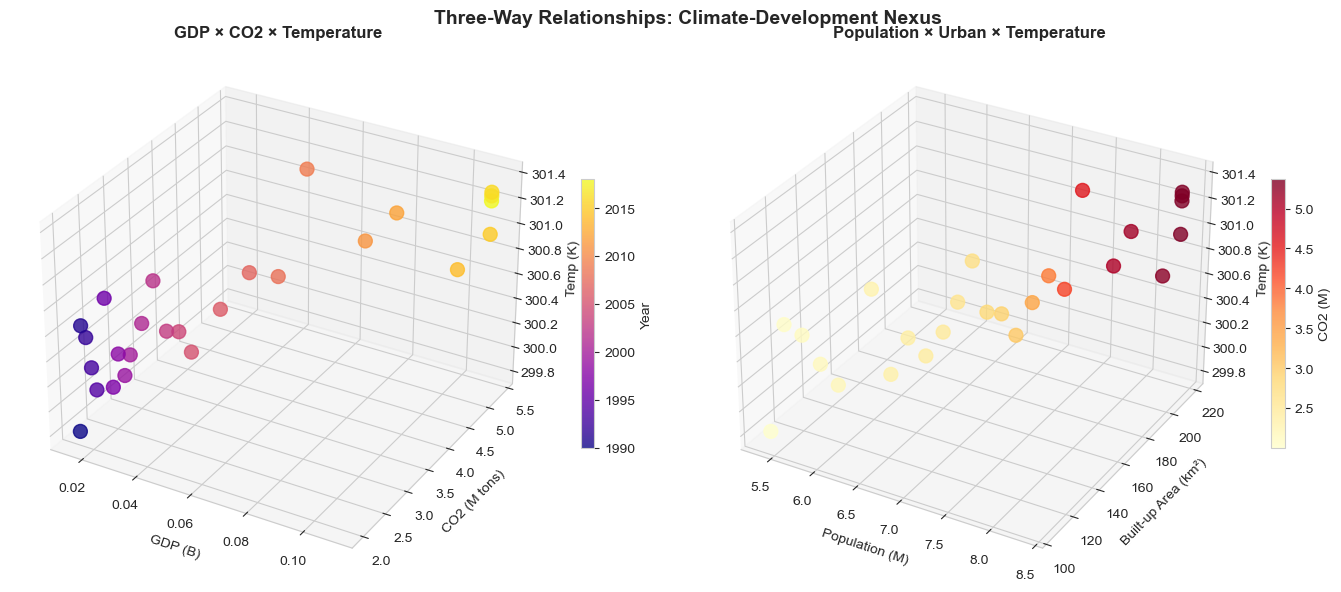


📊 Why important? Visualize complex three-way relationships simultaneously.
📈 What it shows: Development variables cluster together with temperature.


In [42]:
# 3D Relationship: Three Variables at Once
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 6))

# 3D scatter: GDP, CO2, Temperature
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(df_clean['gdp_ppp']/1e9, df_clean['co2_emissions_ton']/1e6, 
                df_clean['temp_mean_K'], c=df_clean.index, cmap='plasma', s=100, alpha=0.8)
ax1.set_xlabel('GDP (B)', fontsize=10)
ax1.set_ylabel('CO2 (M tons)', fontsize=10)
ax1.set_zlabel('Temp (K)', fontsize=10)
ax1.set_title('GDP × CO2 × Temperature', fontsize=12, fontweight='bold')
plt.colorbar(sc1, ax=ax1, shrink=0.5, label='Year')

# 3D scatter: Population, Built-up, Temperature
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(df_clean['population']/1e6, df_clean['built_up_area_m2']/1e6, 
                df_clean['temp_mean_K'], c=df_clean['co2_emissions_ton']/1e6, cmap='YlOrRd', s=100, alpha=0.8)
ax2.set_xlabel('Population (M)', fontsize=10)
ax2.set_ylabel('Built-up Area (km²)', fontsize=10)
ax2.set_zlabel('Temp (K)', fontsize=10)
ax2.set_title('Population × Urban × Temperature', fontsize=12, fontweight='bold')
plt.colorbar(sc2, ax=ax2, shrink=0.5, label='CO2 (M)')

fig.suptitle('Three-Way Relationships: Climate-Development Nexus', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 Why important? Visualize complex three-way relationships simultaneously.")
print("📈 What it shows: Development variables cluster together with temperature.")

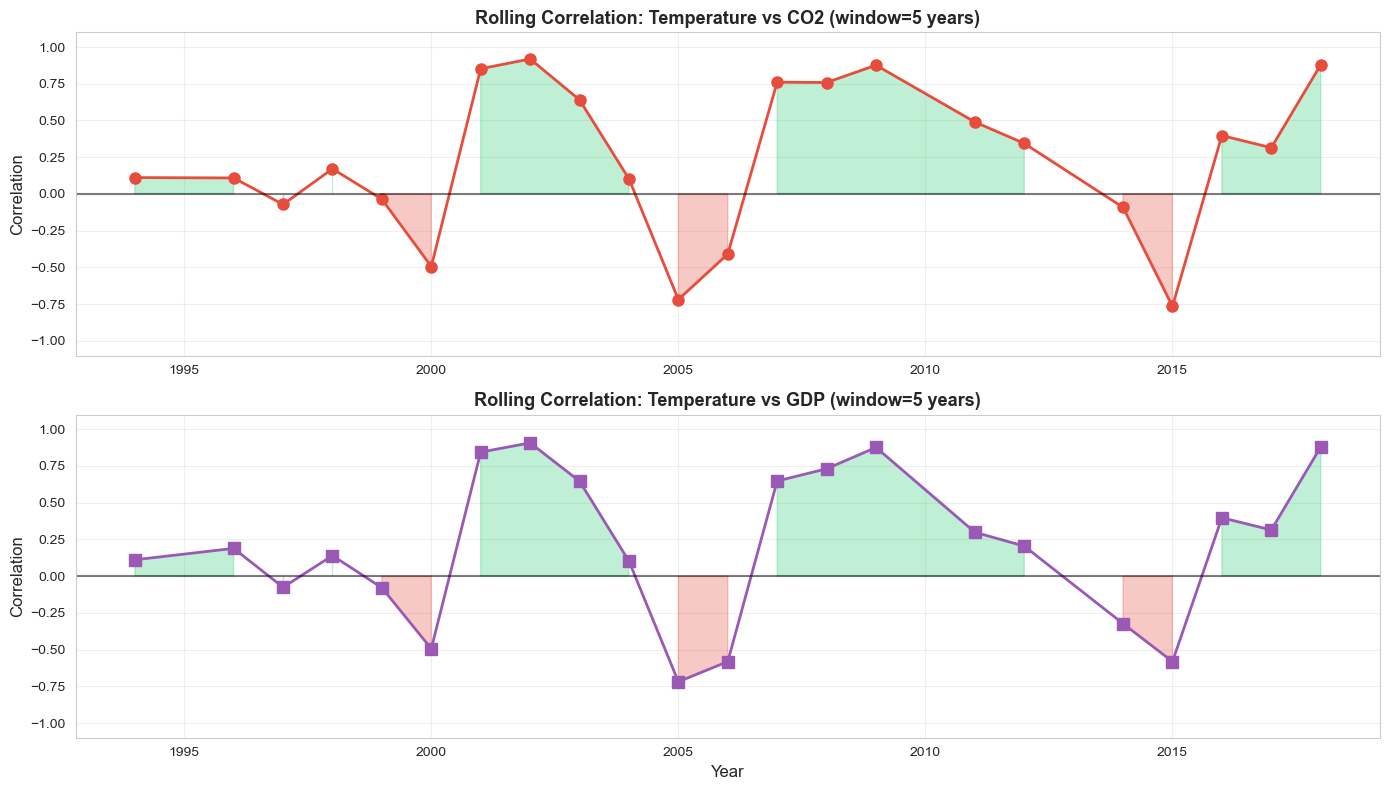


📊 Why important? Shows how relationships evolve over time - not static.
📈 What it shows: Correlation strength varies across different periods.


In [43]:
# Rolling Correlation - How Relationships Change Over Time
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Calculate rolling correlations with 5-year window
window = 5

# Temperature vs CO2 rolling correlation
rolling_corr_co2 = df_clean['temp_mean_K'].rolling(window=window).corr(df_clean['co2_emissions_ton'])
ax1 = axes[0]
ax1.plot(rolling_corr_co2.index, rolling_corr_co2, marker='o', 
         color=COLORS['temperature'], linewidth=2, markersize=8)
ax1.axhline(0, color='black', linestyle='-', alpha=0.5)
ax1.fill_between(rolling_corr_co2.index, 0, rolling_corr_co2, 
                where=rolling_corr_co2 > 0, color=COLORS['positive'], alpha=0.3)
ax1.fill_between(rolling_corr_co2.index, 0, rolling_corr_co2, 
                where=rolling_corr_co2 < 0, color=COLORS['negative'], alpha=0.3)
ax1.set_ylabel('Correlation', fontsize=12)
ax1.set_title(f'Rolling Correlation: Temperature vs CO2 (window={window} years)', 
             fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-1.1, 1.1)

# Temperature vs GDP rolling correlation
rolling_corr_gdp = df_clean['temp_mean_K'].rolling(window=window).corr(df_clean['gdp_ppp'])
ax2 = axes[1]
ax2.plot(rolling_corr_gdp.index, rolling_corr_gdp, marker='s', 
         color=COLORS['gdp'], linewidth=2, markersize=8)
ax2.axhline(0, color='black', linestyle='-', alpha=0.5)
ax2.fill_between(rolling_corr_gdp.index, 0, rolling_corr_gdp, 
                where=rolling_corr_gdp > 0, color=COLORS['positive'], alpha=0.3)
ax2.fill_between(rolling_corr_gdp.index, 0, rolling_corr_gdp, 
                where=rolling_corr_gdp < 0, color=COLORS['negative'], alpha=0.3)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Correlation', fontsize=12)
ax2.set_title(f'Rolling Correlation: Temperature vs GDP (window={window} years)', 
             fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows how relationships evolve over time - not static.")
print("📈 What it shows: Correlation strength varies across different periods.")

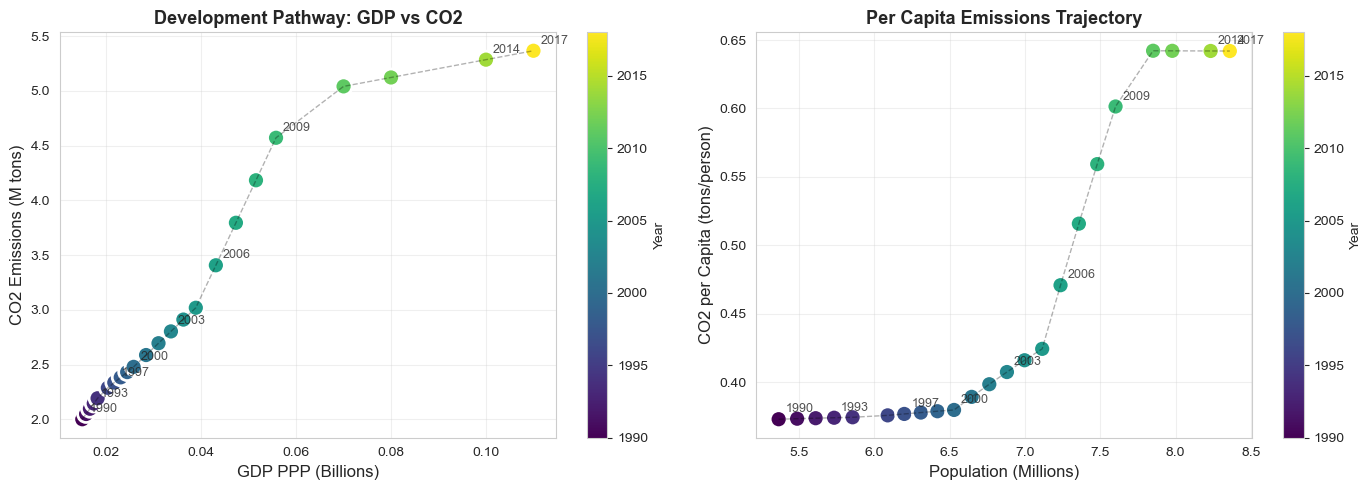


📊 Why important? Shows development pathway and decoupling over time.
📈 What it shows: Early rapid growth, later efficiency gains reduce per-capita emissions.


In [44]:
# Emissions Trajectory - Development Pathway
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CO2 vs GDP trajectory with time coloring
ax1 = axes[0]
sc1 = ax1.scatter(df_clean['gdp_ppp']/1e9, df_clean['co2_emissions_ton']/1e6, 
                 c=df_clean.index, cmap='viridis', s=150, edgecolors='white', linewidth=2)

# Connect points with line
ax1.plot(df_clean['gdp_ppp']/1e9, df_clean['co2_emissions_ton']/1e6, 
         'k--', alpha=0.3, linewidth=1)

# Add year labels
for idx in df_clean.index[::3]:  # Label every 3rd year
    ax1.annotate(str(idx), 
                (df_clean.loc[idx, 'gdp_ppp']/1e9, df_clean.loc[idx, 'co2_emissions_ton']/1e6),
                textcoords="offset points", xytext=(5, 5), fontsize=9, alpha=0.8)

cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('Year')
ax1.set_xlabel('GDP PPP (Billions)', fontsize=12)
ax1.set_ylabel('CO2 Emissions (M tons)', fontsize=12)
ax1.set_title('Development Pathway: GDP vs CO2', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Per capita emissions trajectory
ax2 = axes[1]
sc2 = ax2.scatter(df_clean['population']/1e6, df_clean['co2_per_cap'], 
                 c=df_clean.index, cmap='viridis', s=150, edgecolors='white', linewidth=2)

# Connect points with line
ax2.plot(df_clean['population']/1e6, df_clean['co2_per_cap'], 
         'k--', alpha=0.3, linewidth=1)

# Add year labels
for idx in df_clean.index[::3]:
    ax2.annotate(str(idx), 
                (df_clean.loc[idx, 'population']/1e6, df_clean.loc[idx, 'co2_per_cap']),
                textcoords="offset points", xytext=(5, 5), fontsize=9, alpha=0.8)

cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Year')
ax2.set_xlabel('Population (Millions)', fontsize=12)
ax2.set_ylabel('CO2 per Capita (tons/person)', fontsize=12)
ax2.set_title('Per Capita Emissions Trajectory', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Shows development pathway and decoupling over time.")
print("📈 What it shows: Early rapid growth, later efficiency gains reduce per-capita emissions.")

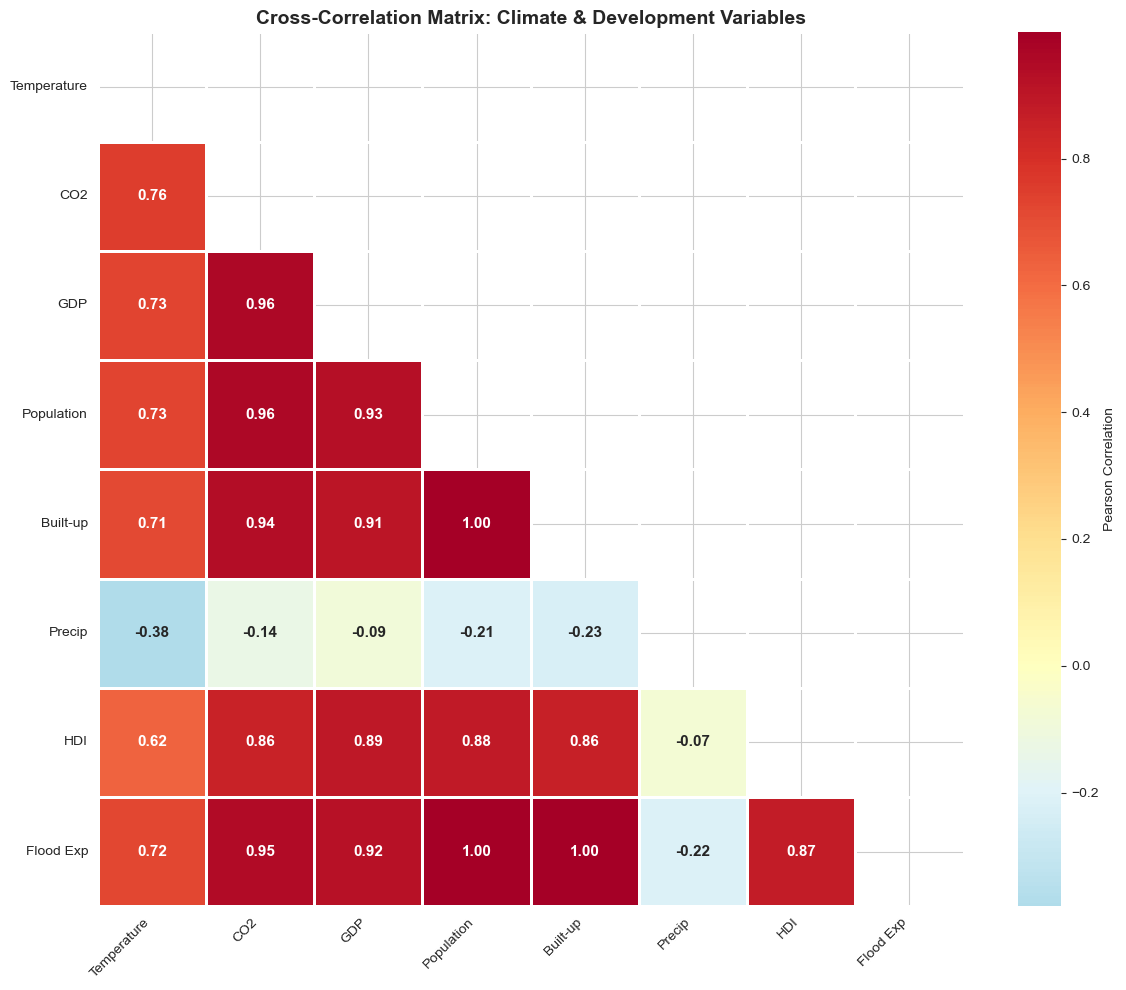


📊 Why important? Full picture of all variable relationships at once.
📈 What it shows: Development variables highly correlated; climate variables more independent.


In [45]:
# Cross-Correlation Matrix - All Key Variables
key_vars = ['temp_mean_K', 'co2_emissions_ton', 'gdp_ppp', 'population', 
           'built_up_area_m2', 'precip_total_mm', 'hdi', 'pop_exposed_flood_10yr']

key_labels = ['Temperature', 'CO2', 'GDP', 'Population', 'Built-up', 'Precip', 'HDI', 'Flood Exp']

# Calculate correlation matrix
corr_matrix = df_clean[key_vars].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Custom colormap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', linewidths=1, ax=ax, annot_kws={'size': 11, 'fontweight': 'bold'},
            xticklabels=key_labels, yticklabels=key_labels,
            cbar_kws={'label': 'Pearson Correlation'})

ax.set_title('Cross-Correlation Matrix: Climate & Development Variables', 
             fontsize=14, fontweight='bold')

# Rotate labels
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print("\n📊 Why important? Full picture of all variable relationships at once.")
print("📈 What it shows: Development variables highly correlated; climate variables more independent.")

---
## Summary

This notebook demonstrated comprehensive climate and development analysis for Hyderabad (1990-2018).

**Key Findings:**
- Temperature shows a gradual warming trend of ~0.5K over the period
- CO2 emissions and GDP grew exponentially (>400%)
- Urban Heat Island effect is observable through built-up area correlation
- Emissions intensity (per GDP) is declining, suggesting efficiency gains
- Flood exposure correlates with precipitation but also depends on other factors

**Color Coding:**
- 🔴 Temperature: Red (#E74C3C)
- 🔵 CO2/Emissions: Blue (#3498DB)
- 🟢 Population: Green (#27AE60)
- 🟣 GDP: Purple (#9B59B6)
- 🔵 Precipitation: Teal (#1ABC9C)